In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time
import mpmath


In [ ]:
class graphWithComplement:

    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

    def add_edge(self, u, v):
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)

    def remove_edge(self, u, v):
        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)

    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)
    
    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m<self.half_of_all_edges:
            return len(nx.common_neighbors(self.graph, u, v))
        else:
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

--- Starting Upsweep ---
Theta2: 0.0000 | Iters: 320000 | Edges: 61533 | Converged: True | 18.59s
Theta2: 0.0010 | Iters: 180000 | Edges: 56723 | Converged: True | 10.82s
Theta2: 0.0021 | Iters: 260000 | Edges: 45286 | Converged: True | 16.26s
Theta2: 0.0031 | Iters: 260000 | Edges: 35241 | Converged: True | 13.57s
Theta2: 0.0041 | Iters: 340000 | Edges: 27139 | Converged: True | 11.61s
Theta2: 0.0051 | Iters: 240000 | Edges: 21379 | Converged: True | 8.29s
Theta2: 0.0062 | Iters: 280000 | Edges: 17083 | Converged: True | 8.41s
Theta2: 0.0072 | Iters: 200000 | Edges: 13971 | Converged: True | 2.97s
Theta2: 0.0082 | Iters: 160000 | Edges: 11549 | Converged: True | 3.87s
Theta2: 0.0092 | Iters: 220000 | Edges: 9715 | Converged: True | 4.97s
Theta2: 0.0103 | Iters: 200000 | Edges: 8199 | Converged: True | 4.21s
Theta2: 0.0113 | Iters: 180000 | Edges: 7045 | Converged: True | 3.65s
Theta2: 0.0123 | Iters: 240000 | Edges: 6213 | Converged: True | 4.55s
Theta2: 0.0133 | Iters: 200000 | Edges

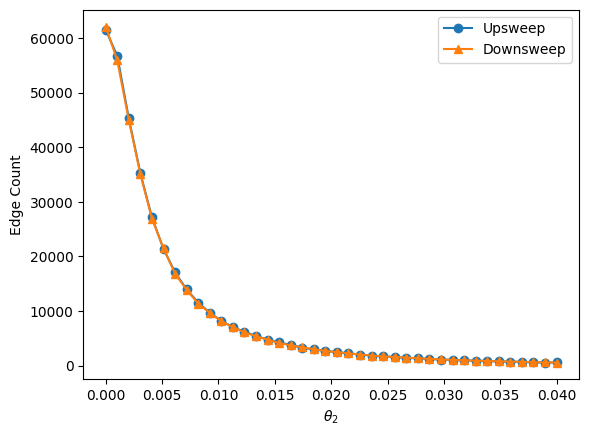

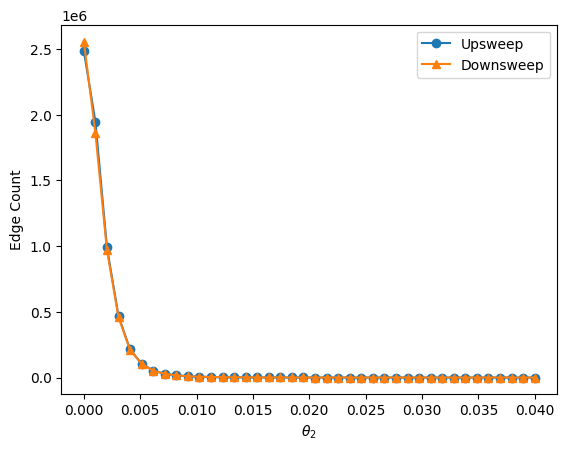

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time

# --- Parameters ---
n = 500
alpha = 44.72822488472924

theta1_vals = np.linspace(0, 0.04, 40)

# --- Simulation Settings ---
max_its = 2_000_000   # Cap to prevent infinite loops
check_interval = 20_000 # Check convergence every 20k steps
tol = 0.005           # 0.5% tolerance for stability

# Storage
up_edges, up_tris = [], []
down_edges, down_tris = [], []

# --- 1. UPSWEEP ---
print("--- Starting Upsweep ---")
# Initialize G once at the start of the sweep (Memory effect = Hysteresis)
G = graphWithComplement(n)
m = G.graph.number_of_edges()
t = sum(nx.triangles(G.graph).values()) // 3

for theta1 in theta1_vals:
    
    # Reset Hamiltonian tracking for this theta2
    H_old_sq = (alpha + theta1 * m) ** 2
    
    # Convergence tracking
    prev_avg_edges = -1 # distinct from any possible value
    prev_avg_tris = -1
    converged = False
    total_iter = 0
    
    start_time = time.time()
    
    # Run in batches until converged or max_its reached
    while total_iter < max_its and not converged:
        
        batch_edges = 0
        batch_tris = 0
        
        # The MCMC Batch
        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j: i, j = np.random.randint(0, n, 2)

            common = G.number_of_common_neighbors(i, j, m)
            
            if G.has_edge(i, j):
                delta_m = -1
                delta_t = -common
                # Proposed change
                m_new = m + delta_m
                t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new) ** 2
                dH = H_old_sq - H_new_sq # Energy minimization
                
                if np.log(np.random.uniform()) <= dH:
                    G.remove_edge(i, j)
                    m = m_new
                    t = t_new
                    H_old_sq = H_new_sq
            else:
                delta_m = 1
                delta_t = common
                m_new = m + delta_m
                t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new) ** 2
                dH = H_old_sq - H_new_sq
                
                if np.log(np.random.uniform()) <= dH:
                    G.add_edge(i, j)
                    m = m_new
                    t = t_new
                    H_old_sq = H_new_sq
            
            # Accumulate stats for this batch
            batch_edges += m
            batch_tris += t
            
        # -- Check Convergence --
        total_iter += check_interval
        avg_edges = batch_edges / check_interval
        avg_tris = batch_tris / check_interval
        
        # Calculate relative change
        if prev_avg_edges > 0: # Skip first check
            diff_e = abs(avg_edges - prev_avg_edges) / (prev_avg_edges + 1e-9)
            diff_t = abs(avg_tris - prev_avg_tris) / (prev_avg_tris + 1e-9)
            
            if diff_e < tol and diff_t < tol:
                converged = True
        
        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris
    
    elapsed = time.time() - start_time
    print(f"Theta2: {theta1:.4f} | Iters: {total_iter} | Edges: {avg_edges:.0f} | Converged: {converged} | {elapsed:.2f}s")
    
    up_edges.append(avg_edges)
    up_tris.append(avg_tris)

# --- 2. DOWNSWEEP ---
print("\n--- Starting Downsweep ---")
# We keep the G from the end of the upsweep to continue the hysteresis loop
for theta1 in reversed(theta1_vals):
    
    H_old_sq = (alpha + theta1 * m) ** 2
    prev_avg_edges = -1
    prev_avg_tris = -1
    converged = False
    total_iter = 0
    start_time = time.time()
    
    while total_iter < max_its and not converged:
        batch_edges = 0
        batch_tris = 0
        
        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j: i, j = np.random.randint(0, n, 2)
            
            common = G.number_of_common_neighbors(i, j, m)
            
            if G.has_edge(i, j):
                delta_m = -1; delta_t = -common
                m_new = m + delta_m; t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new) ** 2
                if np.log(np.random.uniform()) <= (H_old_sq - H_new_sq):
                    G.remove_edge(i, j)
                    m = m_new; t = t_new; H_old_sq = H_new_sq
            else:
                delta_m = 1; delta_t = common
                m_new = m + delta_m; t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new) ** 2
                if np.log(np.random.uniform()) <= (H_old_sq - H_new_sq):
                    G.add_edge(i, j)
                    m = m_new; t = t_new; H_old_sq = H_new_sq
            
            batch_edges += m
            batch_tris += t
            
        total_iter += check_interval
        avg_edges = batch_edges / check_interval
        avg_tris = batch_tris / check_interval
        
        if prev_avg_edges > 0:
            diff_e = abs(avg_edges - prev_avg_edges) / (prev_avg_edges + 1e-9)
            diff_t = abs(avg_tris - prev_avg_tris) / (prev_avg_tris + 1e-9)
            if diff_e < tol and diff_t < tol:
                converged = True
        
        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    elapsed = time.time() - start_time
    print(f"Theta2: {theta1:.4f} | Iters: {total_iter} | Edges: {avg_edges:.0f} | Converged: {converged} | {elapsed:.2f}s")
    
    down_edges.append(avg_edges)
    down_tris.append(avg_tris)

# --- Plotting ---
plt.figure()
plt.plot(theta1_vals, up_edges, 'o-', label='Upsweep')
plt.plot(theta1_vals[::-1], down_edges, '^-', label='Downsweep')
plt.xlabel(r'$\theta_2$')
plt.ylabel('Edge Count')
plt.legend()
plt.figure()
plt.plot(theta1_vals, up_tris, 'o-', label='Upsweep')
plt.plot(theta1_vals[::-1], down_tris, '^-', label='Downsweep')
plt.xlabel(r'$\theta_2$')
plt.ylabel('Edge Count')
plt.legend()
plt.show()


--- Starting Upsweep ---
Theta2: -0.1000 | Iters: 260000 | Edges: 3097 | Converged: True | 4.12s
Theta2: -0.0813 | Iters: 60000 | Edges: 3057 | Converged: True | 0.95s
Theta2: -0.0625 | Iters: 160000 | Edges: 3097 | Converged: True | 2.32s
Theta2: -0.0437 | Iters: 2000000 | Edges: 3120 | Converged: False | 26.13s
Theta2: -0.0250 | Iters: 1540000 | Edges: 3105 | Converged: True | 19.60s
Theta2: -0.0200 | Iters: 500000 | Edges: 3108 | Converged: True | 7.33s
Theta2: -0.0190 | Iters: 2000000 | Edges: 3123 | Converged: False | 26.41s
Theta2: -0.0180 | Iters: 1600000 | Edges: 3097 | Converged: True | 23.05s
Theta2: -0.0170 | Iters: 400000 | Edges: 3104 | Converged: True | 3.33s
Theta2: -0.0160 | Iters: 1420000 | Edges: 3102 | Converged: True | 20.63s
Theta2: -0.0150 | Iters: 40000 | Edges: 3100 | Converged: True | 0.68s
Theta2: -0.0140 | Iters: 320000 | Edges: 3087 | Converged: True | 4.68s
Theta2: -0.0130 | Iters: 1080000 | Edges: 3105 | Converged: True | 13.22s
Theta2: -0.0120 | Iters: 42

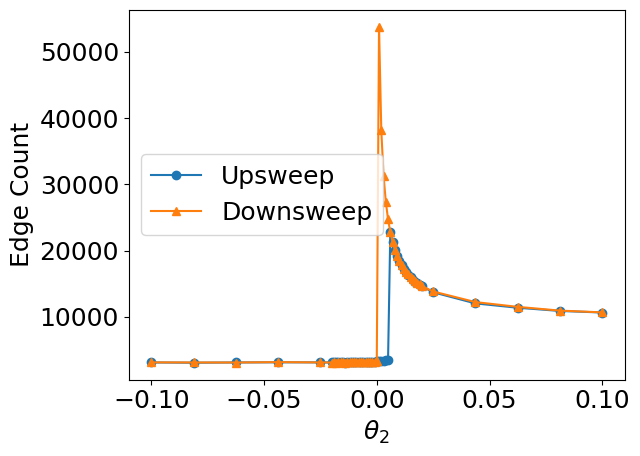

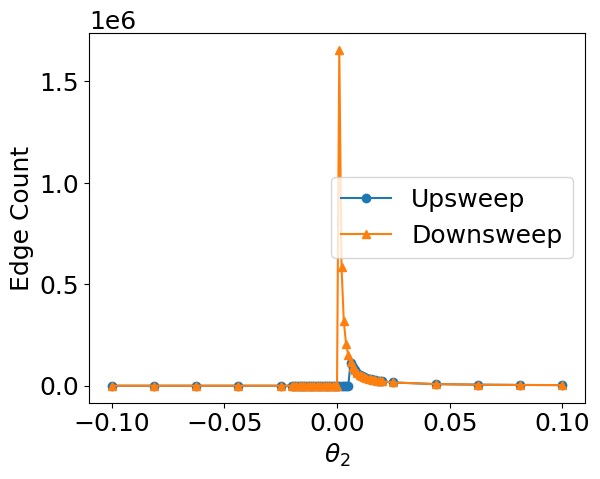

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time

# --- Parameters ---
n = 500
alpha = 44.72822488472924
theta1 = 0.031572151123616235

fine = np.linspace(-0.02, 0.02, 41) 
coarse_neg = np.linspace(-0.1, -0.025, 5)
coarse_pos = np.linspace(0.025, 0.1, 5)
theta2_vals = np.concatenate([coarse_neg, fine, coarse_pos])
theta2_vals.sort()

# --- Simulation Settings ---
max_its = 2_000_000   # Cap to prevent infinite loops
check_interval = 20_000 # Check convergence every 20k steps
tol = 0.005           # 0.5% tolerance for stability

# Storage
up_edges, up_tris = [], []
down_edges, down_tris = [], []

# --- 1. UPSWEEP ---
print("--- Starting Upsweep ---")
# Initialize G once at the start of the sweep (Memory effect = Hysteresis)
G = graphWithComplement(n)
m = G.graph.number_of_edges()
t = sum(nx.triangles(G.graph).values()) // 3

for theta2 in theta2_vals:
    
    # Reset Hamiltonian tracking for this theta2
    H_old_sq = (alpha + theta1 * m + theta2 * t) ** 2
    
    # Convergence tracking
    prev_avg_edges = -1 # distinct from any possible value
    prev_avg_tris = -1
    converged = False
    total_iter = 0
    
    start_time = time.time()
    
    # Run in batches until converged or max_its reached
    while total_iter < max_its and not converged:
        
        batch_edges = 0
        batch_tris = 0
        
        # The MCMC Batch
        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j: i, j = np.random.randint(0, n, 2)

            common = G.number_of_common_neighbors(i, j, m)
            
            if G.has_edge(i, j):
                delta_m = -1
                delta_t = -common
                # Proposed change
                m_new = m + delta_m
                t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new + theta2 * t_new) ** 2
                dH = H_old_sq - H_new_sq # Energy minimization
                
                if np.log(np.random.uniform()) <= dH:
                    G.remove_edge(i, j)
                    m = m_new
                    t = t_new
                    H_old_sq = H_new_sq
            else:
                delta_m = 1
                delta_t = common
                m_new = m + delta_m
                t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new + theta2 * t_new) ** 2
                dH = H_old_sq - H_new_sq
                
                if np.log(np.random.uniform()) <= dH:
                    G.add_edge(i, j)
                    m = m_new
                    t = t_new
                    H_old_sq = H_new_sq
            
            # Accumulate stats for this batch
            batch_edges += m
            batch_tris += t
            
        # -- Check Convergence --
        total_iter += check_interval
        avg_edges = batch_edges / check_interval
        avg_tris = batch_tris / check_interval
        
        # Calculate relative change
        if prev_avg_edges > 0: # Skip first check
            diff_e = abs(avg_edges - prev_avg_edges) / (prev_avg_edges + 1e-9)
            diff_t = abs(avg_tris - prev_avg_tris) / (prev_avg_tris + 1e-9)
            
            if diff_e < tol and diff_t < tol:
                converged = True
        
        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris
    
    elapsed = time.time() - start_time
    print(f"Theta2: {theta2:.4f} | Iters: {total_iter} | Edges: {avg_edges:.0f} | Converged: {converged} | {elapsed:.2f}s")
    
    up_edges.append(avg_edges)
    up_tris.append(avg_tris)

# --- 2. DOWNSWEEP ---
print("\n--- Starting Downsweep ---")
# We keep the G from the end of the upsweep to continue the hysteresis loop
for theta2 in reversed(theta2_vals):
    
    H_old_sq = (alpha + theta1 * m + theta2 * t) ** 2
    prev_avg_edges = -1
    prev_avg_tris = -1
    converged = False
    total_iter = 0
    start_time = time.time()
    
    while total_iter < max_its and not converged:
        batch_edges = 0
        batch_tris = 0
        
        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j: i, j = np.random.randint(0, n, 2)
            
            common = G.number_of_common_neighbors(i, j, m)
            
            if G.has_edge(i, j):
                delta_m = -1; delta_t = -common
                m_new = m + delta_m; t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new + theta2 * t_new) ** 2
                if np.log(np.random.uniform()) <= (H_old_sq - H_new_sq):
                    G.remove_edge(i, j)
                    m = m_new; t = t_new; H_old_sq = H_new_sq
            else:
                delta_m = 1; delta_t = common
                m_new = m + delta_m; t_new = t + delta_t
                H_new_sq = (alpha + theta1 * m_new + theta2 * t_new) ** 2
                if np.log(np.random.uniform()) <= (H_old_sq - H_new_sq):
                    G.add_edge(i, j)
                    m = m_new; t = t_new; H_old_sq = H_new_sq
            
            batch_edges += m
            batch_tris += t
            
        total_iter += check_interval
        avg_edges = batch_edges / check_interval
        avg_tris = batch_tris / check_interval
        
        if prev_avg_edges > 0:
            diff_e = abs(avg_edges - prev_avg_edges) / (prev_avg_edges + 1e-9)
            diff_t = abs(avg_tris - prev_avg_tris) / (prev_avg_tris + 1e-9)
            if diff_e < tol and diff_t < tol:
                converged = True
        
        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    elapsed = time.time() - start_time
    print(f"Theta2: {theta2:.4f} | Iters: {total_iter} | Edges: {avg_edges:.0f} | Converged: {converged} | {elapsed:.2f}s")
    
    down_edges.append(avg_edges)
    down_tris.append(avg_tris)

# --- Plotting ---
plt.figure()
plt.plot(theta2_vals, up_edges, 'o-', label='Upsweep')
plt.plot(theta2_vals[::-1], down_edges, '^-', label='Downsweep')
plt.xlabel(r'$\theta_2$')
plt.ylabel('Edge Count')
plt.legend()
plt.figure()
plt.plot(theta2_vals, up_tris, 'o-', label='Upsweep')
plt.plot(theta2_vals[::-1], down_tris, '^-', label='Downsweep')
plt.xlabel(r'$\theta_2$')
plt.ylabel('Edge Count')
plt.legend()
plt.show()


In [ ]:
import mpmath 
mpmath.mp.dps = 50




In [ ]:
def f(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    for m in range(nc2+1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m)*mpmath.exp(-square_term * square_term)
    return total - 1

In [ ]:
def derivative(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    for m in range(nc2+1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m)*mpmath.exp(-square_term * square_term)*(-2*square_term)
    return total

In [ ]:
beta = 1
n=100
nc2 = mpmath.binomial(n, 2)
alpha = mpmath.findroot(lambda alpha: f(alpha, beta, nc2), 0, derivative = lambda alpha: derivative(alpha, beta, nc2), tol = 1e-10, verify=False)
print(alpha, f(alpha, beta, nc2))

-2.1076847854672156058432564404991120706356454318558 1.8932971203503117275095073203444418023562274320189e-16


In [ ]:
import mpmath
import matplotlib.pyplot as plt
import time

# Set high precision
mpmath.dps = 50

def f(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m) * mpmath.exp(-square_term * square_term)
        if total == prev_total:
            break
        prev_total = total
    return total - 1

def derivative(alpha, beta, nc2):
    nc2 = int(nc2)
    total = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        total += mpmath.binomial(nc2, m) * mpmath.exp(-square_term * square_term) * (-2 * square_term)
        if total == prev_total:
            break
        prev_total = total
    return total

def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy += mpmath.binomial(nc2, m) * entropy
        if total_entropy == prev_total:
            break
        prev_total = total_entropy
    return total_entropy

n_values = range(10, 100, 10)

mpmath.mp.dps = 50
plt.figure(figsize=(10, 6))
beta_alpha_lists = []
for beta in [0.05, 0.1, 0.3, 1]:
    results_n = []
    results_entropy = []
    alpha_list = []
    start_guess = 0
    for n_val in n_values:
        start_time = time.time()
        n = mpmath.mpf(n_val)
        nc2 = mpmath.binomial(n, 2)
        try:
            alpha = mpmath.findroot(lambda alpha: f(alpha, beta, nc2), start_guess, derivative = lambda alpha: derivative(alpha, beta, nc2), tol = 1e-10, maxsteps = 1000)
            alpha_list.append((n_val, float(alpha)))
            start_guess = alpha  # Update start guess for next iteration
            entropy = calculate_entropy(alpha, beta, nc2)
            
            results_n.append(n_val)
            results_entropy.append(float(entropy)) 
            
            print(f"n = {n_val}, nc2 = {int(nc2)}, alpha = {alpha}, Entropy = {entropy} (took {time.time() - start_time:.2f}s)")
        
        except Exception as e:
            print(f"  Failed to find root for n = {n_val}: {e}, {beta}")
    beta_alpha_lists.append((beta, alpha_list))
    if results_n:
        plt.plot(results_n, results_entropy, 'o-', label=f'beta={beta}')
    else:
        print("No results to plot.")

beta = 0
results_n = []
results_entropy = []
alpha_list = []
for n_val in range(10, 100, 20):
    start_time = time.time()
    n = mpmath.mpf(n_val)
    nc2 = mpmath.binomial(n, 2)
    try:
        alpha = -mpmath.sqrt(nc2*mpmath.log(2))
        alpha_list.append((n_val, float(alpha)))
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy = (2**(nc2)) * entropy
        
        results_n.append(n_val)
        results_entropy.append(float(total_entropy)) 
        
        print(f"n = {n_val}, nc2 = {int(nc2)}, alpha = {alpha}, Entropy = {entropy} (took {time.time() - start_time:.2f}s)")
    
    except Exception as e:
        print(f"  Failed to find root for n = {n_val}: {e}, {beta}")
beta_alpha_lists.append((beta, alpha_list))
if results_n:
     plt.plot(results_n, results_entropy, 'o-', label=f'beta={beta}')
else:
    print("No results to plot.")

print(beta_alpha_lists)
plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy')
plt.title('Entropy vs. n')
plt.grid(True)
plt.legend()
plt.show()

n = 10, nc2 = 45, alpha = -4.6106827877400094781700937521581580664726671707036, Entropy = 5.5273996961549141003401728053286713429666343157181 (took 0.18s)
n = 20, nc2 = 190, alpha = -7.9605753753663735477817711049828455801859600731782, Entropy = 10.481246742479970254360303651801479537908297170172 (took 1.06s)
n = 30, nc2 = 435, alpha = -10.405835657765873990560287331601073743812500895238, Entropy = 14.560197942478419707585874523798875933853350918565 (took 2.72s)


KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

In [ ]:
n = 200
nc2 = mpmath.binomial(n, 2)
beta = 3
start_guess = 0
alpha = mpmath.findroot(lambda alpha: f(alpha, beta, nc2), start_guess, derivative = lambda alpha: derivative(alpha, beta, nc2), tol = 1e-10)
print(alpha, f(alpha, beta, nc2), calculate_entropy(alpha, beta, nc2))
#symmetry 
print(nc2*beta-alpha,f(nc2*beta-alpha, beta, nc2), calculate_entropy(nc2*beta-alpha, beta, nc2))



-0.42214426387951477333703624953515142616335359452487 1.8326281181620585538338657885270081812852185726877e-41 1.4226463217044382617904733885273682042992277343066
59700.422144263879514773337036249535151426163353595 1.8326325977157126683537687200661271271688474669577e-41 1.4226463217044382617904733885273682042992277344078


-0.42214426387951476
Iteration 50000, edges: 838, triangles: 97
Iteration 100000, edges: 47, triangles: 0
Iteration 150000, edges: 2, triangles: 0
Iteration 200000, edges: 0, triangles: 0
Iteration 250000, edges: 1, triangles: 0
Iteration 300000, edges: 0, triangles: 0
Iteration 350000, edges: 0, triangles: 0
Iteration 400000, edges: 0, triangles: 0
Iteration 450000, edges: 0, triangles: 0


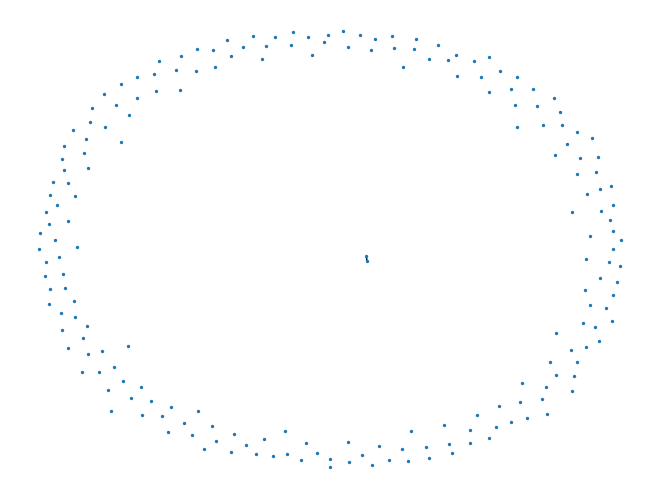

59700.422144263879514758386335415707435458898544312
Iteration 50000, edges: 19088, triangles: 1159036
Iteration 100000, edges: 19837, triangles: 1300967
Iteration 150000, edges: 19897, triangles: 1312806
Iteration 200000, edges: 19900, triangles: 1313400
Iteration 250000, edges: 19900, triangles: 1313400
Iteration 300000, edges: 19900, triangles: 1313400
Iteration 350000, edges: 19900, triangles: 1313400
Iteration 400000, edges: 19900, triangles: 1313400
Iteration 450000, edges: 19900, triangles: 1313400


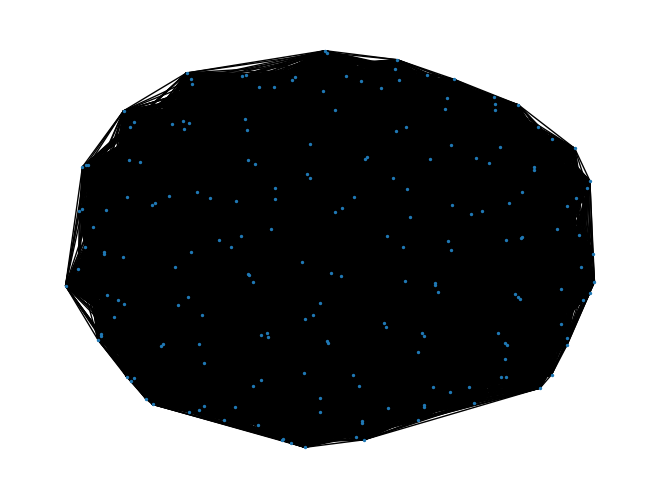

In [ ]:
n = 200
alpha = -0.42214426387951477333703624953515142616335359452487 #lagrangian multiplier for sum of P = 1 constraint
print(alpha)
theta1 = 3
G = graphWithComplement(n, p=0.5)
m= G.graph.number_of_edges()
t = sum(nx.triangles(G.graph).values()) // 3
its = 500000
burn_in = 50000
H_old_sq = (alpha - theta1 * m) ** 2

for _ in range(its):
    if _ % 50000 == 0 and _ > 0:
        print(f"Iteration {_}, edges: {m}, triangles: {t}")
    i, j = np.random.randint(0, n, 2)
    while(i==j):
        i, j = np.random.randint(0, n, 2)
    if G.has_edge(i, j):
        delta_t = -G.number_of_common_neighbors(i, j, m)
        delta_m = -1
        G.remove_edge(i, j)
    else:
        delta_t = G.number_of_common_neighbors(i, j, m)
        delta_m = 1
        G.add_edge(i, j)
    
    t_new = t + delta_t
    m_new = m + delta_m
    H_new_sq = (alpha - theta1 * m_new) ** 2

    dH = H_old_sq - H_new_sq
    if np.log(np.random.uniform()) <= dH:
        m += delta_m
        t += delta_t
        H_old_sq = H_new_sq
    else:
        # revert
        if delta_m == -1:
            G.add_edge(i, j)
        else:
            G.remove_edge(i, j)

nx.draw(G.graph, node_size = 2)
plt.show()
alpha = mpmath.binomial(n, 2)*beta-alpha
print(alpha)
theta1 = 3
G = graphWithComplement(n, p=0.5)
m= G.graph.number_of_edges()
t = sum(nx.triangles(G.graph).values()) // 3
its = 500000
burn_in = 50000
H_old_sq = (alpha - theta1 * m) ** 2
for _ in range(its):
    if _ % 50000 == 0 and _ > 0:
        print(f"Iteration {_}, edges: {m}, triangles: {t}")
    i, j = np.random.randint(0, n, 2)
    while(i==j):
        i, j = np.random.randint(0, n, 2)
    if G.has_edge(i, j):
        delta_t = -G.number_of_common_neighbors(i, j, m)
        delta_m = -1
        G.remove_edge(i, j)
    else:
        delta_t = G.number_of_common_neighbors(i, j, m)
        delta_m = 1
        G.add_edge(i, j)
    
    t_new = t + delta_t
    m_new = m + delta_m
    H_new_sq = (alpha - theta1 * m_new) ** 2

    dH = H_old_sq - H_new_sq
    if np.log(np.random.uniform()) <= dH:
        m += delta_m
        t += delta_t
        H_old_sq = H_new_sq
    else:
        # revert
        if delta_m == -1:
            G.add_edge(i, j)
        else:
            G.remove_edge(i, j)
nx.draw(G.graph, node_size = 2)
plt.show()


In [ ]:
import mpmath
mpmath.dps = 50
mpmath.mp.dps = 50
def find_alpha_beta(n, m_star):
    nc2 = int(mpmath.binomial(n, 2))
    def equations(alpha, beta):
        total_prob = 0
        prev_total_prob = -1
        expected_edges = 0
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            square_term = alpha - beta * m
            prob_m_edges = mpmath.binomial(nc2, m) * mpmath.exp(-square_term * square_term)
            total_prob += prob_m_edges
            expected_edges += m * prob_m_edges
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
        return [total_prob - 1, expected_edges - m_star]
    def jacobian(alpha, beta):
        # J11: d(prob)/d(alpha)
        # J12: d(prob)/d(beta)
        # J21: d(edges)/d(alpha)
        # J22: d(edges)/d(beta)
        J11 = 0; J12 = 0
        J21 = 0; J22 = 0
        prev_J = [None, None, None, None]
        
        for m in range(int(nc2) + 1):
            term = alpha - beta * m

            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term * term)
            
            # -2 * (alpha - beta*m)
            deriv_factor = -2 * term
            
            # Partial w.r.t Alpha
            d_alpha = base_prob * deriv_factor
            
            # Partial w.r.t Beta
            d_beta = base_prob * deriv_factor * (-m)
            
            # Row 1 (Sum of probs)
            J11 += d_alpha
            J12 += d_beta
            
            # Row 2 (Expected edges)
            J21 += m * d_alpha
            J22 += m * d_beta

            # EARLY STOPPING
            # Pack current values into a list for easy comparison
            current_J = [J11, J12, J21, J22]
            
            # Only stop if we passed the target peak AND values stopped changing
            if m > m_star and current_J == prev_J:
                break
                
            prev_J = current_J
            
        return [[J11, J12], [J21, J22]]
    beta_start = 0.1
    alpha_start = beta_start * m_star
    roots = mpmath.findroot(equations, [alpha_start, beta_start], J=jacobian,tol=1e-4, maxsteps = 1000)
    return roots

n=10
m_star = 16
roots = find_alpha_beta(n, m_star)
print(roots)

[ -4.5305639473170749885932781612879335873834941976056]
[0.054898581812713759623329661249134065470725701123233]


Target   | Alpha      | Beta      
-----------------------------------
1.0
1.0 | 1.5651252545180472 | -1.3838606268133522
261.42105263157894736842105263157894736842105263158
261.42105263157894736842105263157894736842105263158 | 20.188357471666865 | -0.04511587633653198
521.84210526315789473684210526315789473684210526316
521.84210526315789473684210526315789473684210526316 | 27.167097722200744 | -0.026182216415776328
782.26315789473684210526315789473684210526315789474
782.26315789473684210526315789473684210526315789474 | 32.39757355105589 | -0.017996390088371714
1042.6842105263157894736842105263157894736842105263
1042.6842105263157894736842105263157894736842105263 | 36.8366626954667 | -0.013084286738953078
1303.1052631578947368421052631578947368421052631579
1303.1052631578947368421052631578947368421052631579 | 40.863369588239784 | -0.009632791584393365
1563.5263157894736842105263157894736842105263157895
1563.5263157894736842105263157894736842105263157895 | 44.69026844328389 | -0.00695444

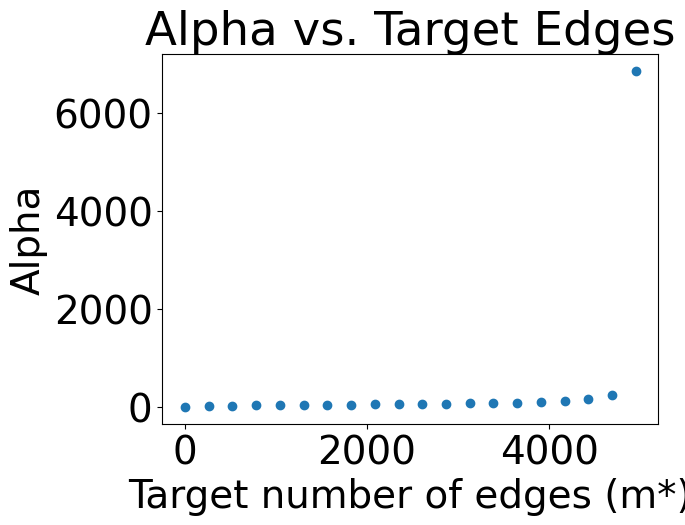

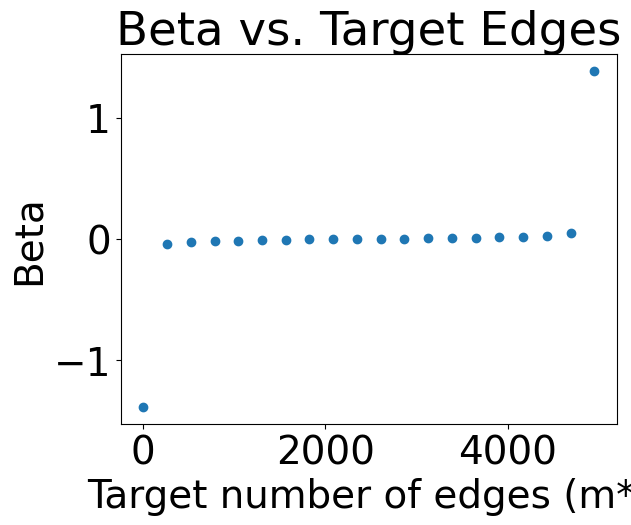

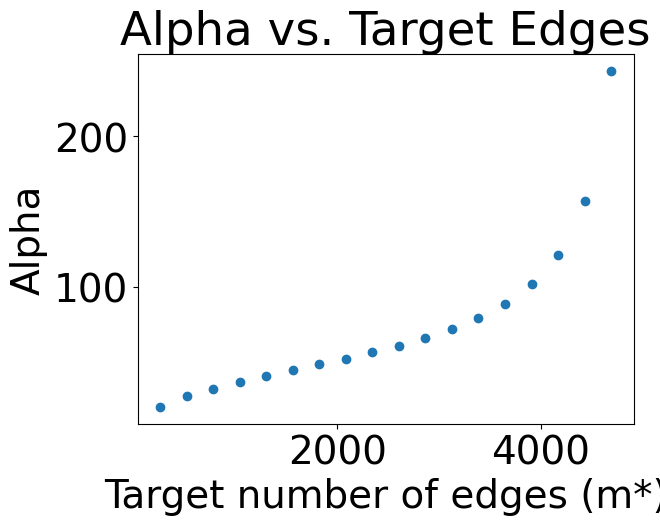

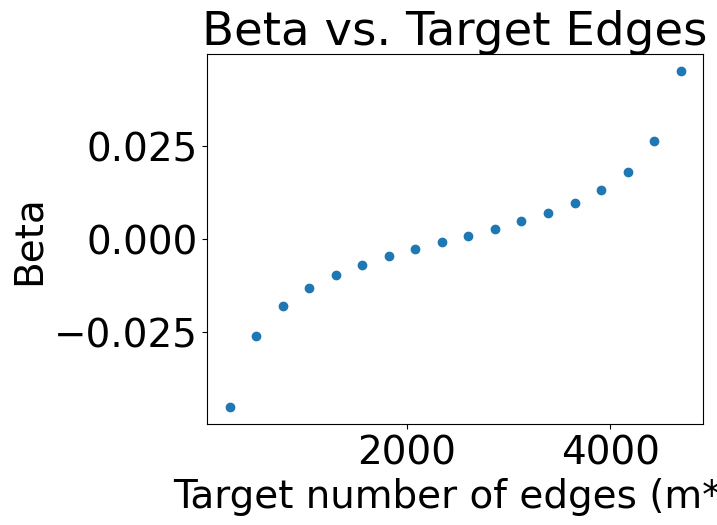

In [4]:
import mpmath
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Set precision (50 digits is sufficient for n=10, use 100+ for n>50)
mpmath.mp.dps = 50
mpmath.dps = 50

def solve_network_parameters(n, m_star):
    nc2 = int(mpmath.binomial(n, 2))
    
    # We derive the guess by matching the peak of the Gaussian to the Binomial.
    # 1. The Binomial coefficient at m_star is huge: B = binom(nc2, m_star)
    # 2. We need exp(-(alpha - beta*m)^2) * B approx 1 (Normalization)
    #    Therefore: (alpha - beta*m)^2 approx ln(B)
    # 3. We need the slopes to cancel at m_star (Derivative matching)
    
    # Log of the Binomial Coefficient (The "Height" we must suppress)
    ln_B = mpmath.log(mpmath.binomial(nc2, m_star))
    
    # The slope of the Log-Binomial distribution at m_star
    # S = ln((N - m)/m)
    binom_slope = mpmath.log((nc2 - m_star) / m_star)
    
    # Calculate parameters
    # delta represents (alpha - beta*m_star)
    delta = mpmath.sqrt(ln_B)
    
    # Derived Beta and Alpha
    # beta = -Slope / (2 * delta)
    beta_guess = -binom_slope / (2 * delta)
    alpha_guess = beta_guess * m_star + delta

    def equations(alpha, beta):
        total_prob = 0
        expected_edges = 0
        prev_total_prob = -1
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            term = alpha - beta * m
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term*term)
            total_prob += prob
            expected_edges += m * prob
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
            
        return [total_prob - 1, expected_edges - m_star]

    def jacobian(alpha, beta):
        J11 = 0; J12 = 0; J21 = 0; J22 = 0
        prev_J = [None, None, None, None]
        for m in range(nc2 + 1):
            term = alpha - beta * m
            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term**2)
            deriv_factor = -2 * term
            
            d_alpha = base_prob * deriv_factor
            d_beta = base_prob * deriv_factor * (-m)
            
            J11 += d_alpha; J12 += d_beta
            J21 += m * d_alpha; J22 += m * d_beta
            current_J = [J11, J12, J21, J22]
            
            # Only stop if we passed the target peak AND values stopped changing
            if m > m_star and current_J == prev_J:
                break
                
            prev_J = current_J
        return [[J11, J12], [J21, J22]]

    # --- 4. Solver Execution with Fallback ---
    # Priority 1: MDNewton (Fastest, Exact)
    # Priority 2: Anderson (Gradient-free, Robust against 0-derivatives)
    # Priority 3: Secant (Simple fallback)
    solvers = ['mdnewton', 'anderson', 'secant']
    
    for solver in solvers:
        try:
            kwargs = {'tol': 1e-10}
            if solver == 'mdnewton':
                kwargs['J'] = jacobian # Only pass Jacobian to Newton
            
            root = mpmath.findroot(equations, [alpha_guess, beta_guess], solver=solver, **kwargs)
            return float(root[0]), float(root[1])
            
        except Exception:
            continue
            
    print(f"  [Error] All solvers failed for m={m_star}")
    return None, None

# --- Verification Run ---
n = 100
nc2 = mpmath.binomial(n, 2)
# Testing the tricky range where previous codes failed
test_points = np.linspace(1, nc2-1, 20)

print(f"{'Target':<8} | {'Alpha':<10} | {'Beta':<10}")
print("-" * 35)

m_star_list = []
alpha_list = []
beta_list =[]
for m_star in test_points:
    alpha, beta = solve_network_parameters(n, m_star)
    print(m_star)
    if alpha is not None:
        print(f"{m_star} | {alpha} | {beta}")
        m_star_list.append(m_star)
        alpha_list.append(alpha)
        beta_list.append(beta)

plt.figure()
matplotlib.rcParams.update({'font.size': 28})
plt.scatter(m_star_list, alpha_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')
plt.figure()
plt.scatter(m_star_list, beta_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.figure()

plt.scatter(m_star_list[1:-1], alpha_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')

plt.figure()
plt.scatter(m_star_list[1:-1], beta_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.show()


In [2]:
import mpmath
import matplotlib.pyplot as plt
mpmath.dps = 50
def solve_network_parameters(n, m_star):
    nc2 = int(mpmath.binomial(n, 2))
    
    # We derive the guess by matching the peak of the Gaussian to the Binomial.
    # 1. The Binomial coefficient at m_star is huge: B = binom(nc2, m_star)
    # 2. We need exp(-(alpha - beta*m)^2) * B approx 1 (Normalization)
    #    Therefore: (alpha - beta*m)^2 approx ln(B)
    # 3. We need the slopes to cancel at m_star (Derivative matching)
    
    # Log of the Binomial Coefficient (The "Height" we must suppress)
    ln_B = mpmath.log(mpmath.binomial(nc2, m_star))
    
    # The slope of the Log-Binomial distribution at m_star
    # S = ln((N - m)/m)
    binom_slope = mpmath.log((nc2 - m_star) / m_star)
    
    # Calculate parameters
    # delta represents (alpha - beta*m_star)
    delta = mpmath.sqrt(ln_B)
    
    # Derived Beta and Alpha
    # beta = -Slope / (2 * delta)
    beta_guess = -binom_slope / (2 * delta)
    alpha_guess = beta_guess * m_star + delta

    def equations(alpha, beta):
        total_prob = 0
        expected_edges = 0
        prev_total_prob = -1
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            term = alpha - beta * m
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term*term)
            total_prob += prob
            expected_edges += m * prob
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
            
        return [total_prob - 1, expected_edges - m_star]

    def jacobian(alpha, beta):
        J11 = 0; J12 = 0; J21 = 0; J22 = 0
        prev_J = [None, None, None, None]
        for m in range(nc2 + 1):
            term = alpha - beta * m
            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term**2)
            deriv_factor = -2 * term
            
            d_alpha = base_prob * deriv_factor
            d_beta = base_prob * deriv_factor * (-m)
            
            J11 += d_alpha; J12 += d_beta
            J21 += m * d_alpha; J22 += m * d_beta
            current_J = [J11, J12, J21, J22]
            
            # Only stop if we passed the target peak AND values stopped changing
            if m > m_star and current_J == prev_J:
                break
                
            prev_J = current_J
        return [[J11, J12], [J21, J22]]

    # --- 4. Solver Execution with Fallback ---
    # Priority 1: MDNewton (Fastest, Exact)
    # Priority 2: Anderson (Gradient-free, Robust against 0-derivatives)
    # Priority 3: Secant (Simple fallback)
    solvers = ['mdnewton', 'anderson', 'secant']
    
    for solver in solvers:
        try:
            kwargs = {'tol': 1e-10}
            if solver == 'mdnewton':
                kwargs['J'] = jacobian # Only pass Jacobian to Newton
            
            root = mpmath.findroot(equations, [alpha_guess, beta_guess], solver=solver, **kwargs)
            print(f"  [Success] Solver '{solver}' converged for m={m_star}")
            return float(root[0]), float(root[1])
            
        except Exception:
            continue
            
    print(f"  [Error] All solvers failed for m={m_star}")
    return None, None
def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy += mpmath.binomial(nc2, m) * entropy
        if total_entropy == prev_total:
            break
        prev_total = total_entropy
    return total_entropy

def check_equations(alpha, beta, nc2, m_star):
        total_prob = 0
        expected_edges = 0
        prev_total_prob = -1
        prev_expected_edges = -1
        for m in range(nc2 + 1):
            term = alpha - beta * m
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term*term)
            total_prob += prob
            expected_edges += m * prob
            if m>m_star and total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges
            
        return [total_prob, expected_edges]

entropy_list = []
n_list = [10, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
for n in n_list:
    nc2 = mpmath.binomial(n, 2)
    m_star = 2*n
    alpha, beta = solve_network_parameters(n, m_star)
    if alpha is not None:
        entropy = calculate_entropy(alpha, beta, nc2)
        entropy_list.append(float(entropy))
        total_prob, expected_edges = check_equations(alpha, beta, int(nc2), m_star)
        print(f"n={n}, m*={m_star}, alpha={alpha}, beta={beta}, Entropy={entropy}, total_prob={total_prob}, expected_edges={expected_edges}")

matplotlib.rcParams.update({'font.size': 28})
plt.figure()
plt.scatter(n_list, entropy_list)
plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy')
plt.title('Entropy vs. n for m* = 2n')
plt.show() 

    


  [Success] Solver 'mdnewton' converged for m=20
n=10, m*=20, alpha=5.158281270203757, beta=-0.020064430594303476, Entropy=5.64812729475604, total_prob=0.999999999999998, expected_edges=20.0
  [Success] Solver 'mdnewton' converged for m=1000
n=500, m*=1000, alpha=44.72822488472924, beta=-0.031572151123616235, Entropy=76.3069288673033, total_prob=1.0000000000038, expected_edges=1000.00000000379
  [Success] Solver 'mdnewton' converged for m=2000
n=1000, m*=2000, alpha=65.86316479205864, beta=-0.02415674992764256, Entropy=114.181043775516, total_prob=1.00000000000124, expected_edges=2000.00000000247
  [Success] Solver 'mdnewton' converged for m=3000
n=1500, m*=3000, alpha=82.48624975379312, beta=-0.02054870778828984, Entropy=144.135842128153, total_prob=0.999999999999151, expected_edges=2999.99999999745
  [Success] Solver 'mdnewton' converged for m=4000
n=2000, m*=4000, alpha=96.71453922308628, beta=-0.018285892424266797, Entropy=169.861052540116, total_prob=1.00000000000282, expected_edg

NameError: name 'matplotlib' is not defined

In [3]:
print(entropy_list)

[5.648127294756035, 76.30692886730333, 114.18104377551563, 144.13584212815326, 169.86105254011585, 192.82917102930136, 213.81010047897226, 233.26782408735482, 251.50814070422226, 268.74549393991714, 285.13729648683443]


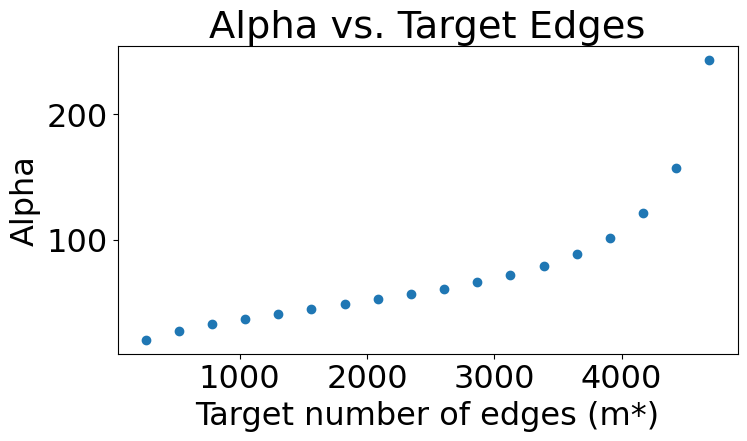

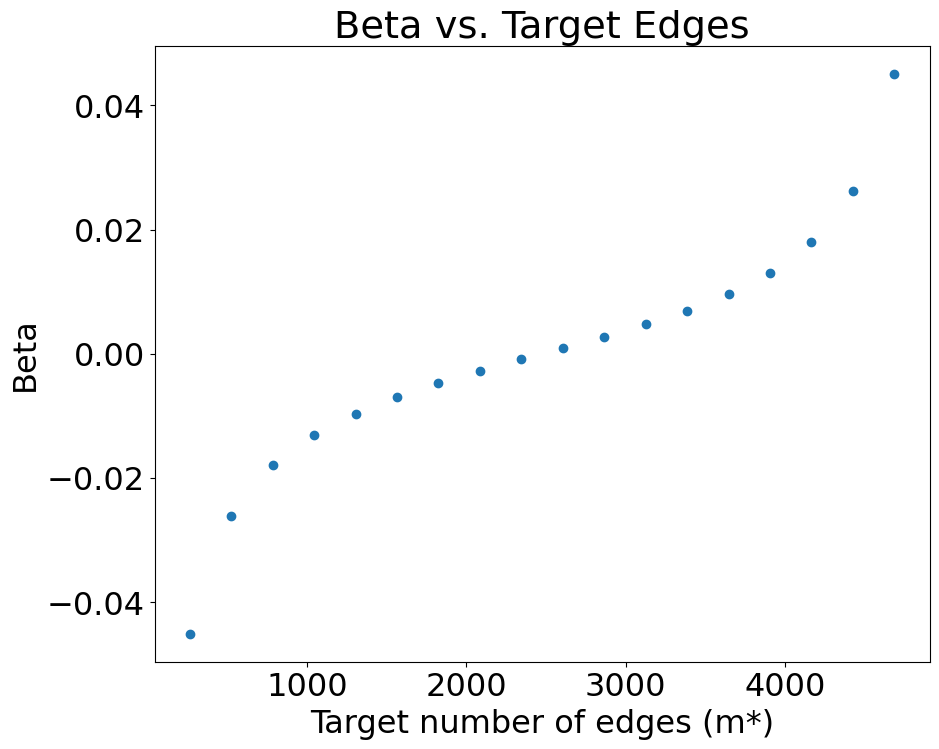

In [14]:
matplotlib.rcParams.update({'font.size': 23})
plt.figure(figsize=(8, 4))
plt.scatter(m_star_list[1:-1], alpha_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')

plt.figure(figsize=(10, 8))
plt.scatter(m_star_list[1:-1], beta_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.show()

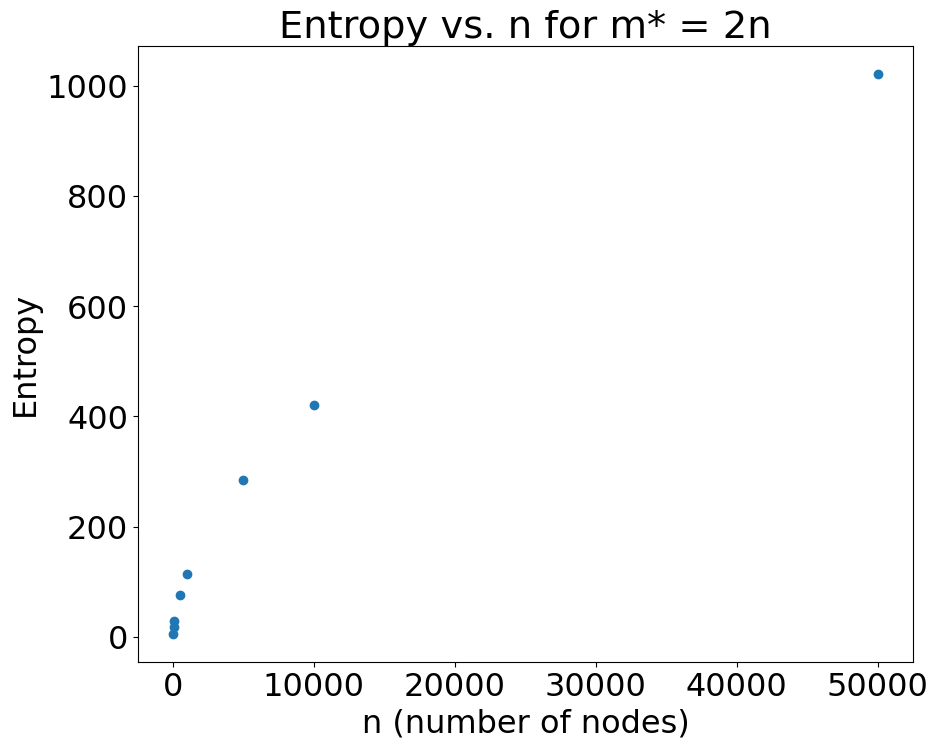

In [11]:
matplotlib.rcParams.update({'font.size': 23})
plt.figure(figsize=(10, 8))
plt.scatter(n_list, entropy_list)
plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy')
plt.title('Entropy vs. n for m* = 2n')
plt.show() 


n=10, Entropy=30.9133
n=30, Entropy=174.5176
n=50, Entropy=346.3551
n=100, Entropy=837.6692
n=200, Entropy=1958.7569
n=300, Entropy=3184.4581
n=400, Entropy=4478.1102
n=500, Entropy=5822.2930
n=600, Entropy=7206.7451
n=700, Entropy=8624.6855
n=800, Entropy=10071.2948
n=900, Entropy=11542.9692
n=1000, Entropy=13036.9115


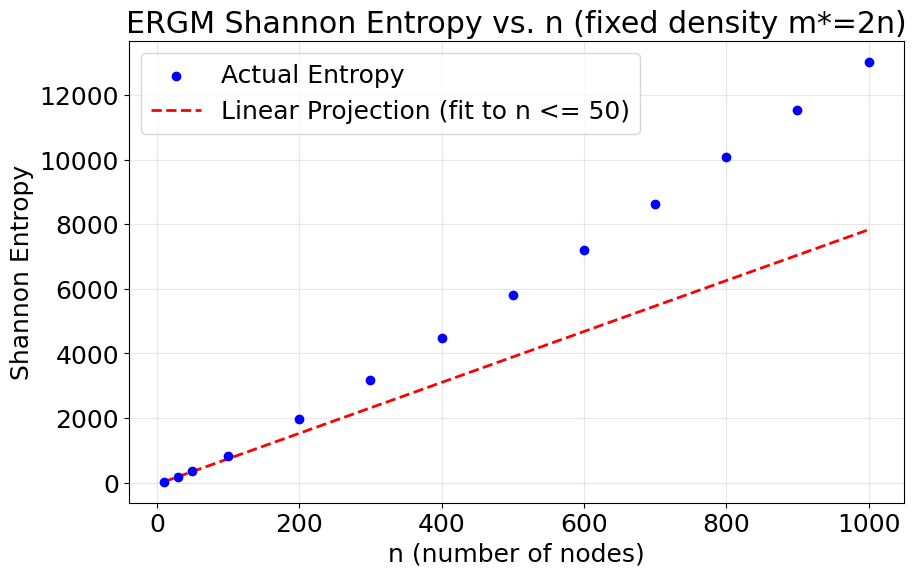

<Figure size 640x480 with 0 Axes>

In [ ]:
import mpmath
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Set precision for mpmath to handle large exponents/binomials
mpmath.mp.dps = 50

def solve_network_parameters(n, m_star):
    """
    Solves for the standard ERGM parameters (Bernoulli Graph / Erdős-Rényi).
    P(G) = exp(alpha - beta * m)
    """
    nc2 = mpmath.binomial(n, 2)
    
    # Probability of an edge existing
    p = m_star / nc2
    
    # In standard ERGM/Logistic regression: beta = logit(p)
    beta = -mpmath.log(p / (1 - p))
    
    # Analytic simplification: alpha = nc2 * ln(1 - p)
    alpha = nc2 * mpmath.log(1 - p)
    
    return alpha, beta

def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    
    # We iterate m starting from 0. 
    for m in range(nc2 + 1):
        log_p_g = alpha - beta * m
        p_g = mpmath.exp(log_p_g)
        
        num_graphs = mpmath.binomial(nc2, m)
        
        # S_shell = binom(nc2, m) * p_g * (-log_p_g)
        current_term = num_graphs * p_g * (-log_p_g)
        
        total_entropy += current_term
        
        # Convergence check
        if m > 2*n and total_entropy == prev_total:
            break
            
        prev_total = total_entropy
        
    return total_entropy

ergm_entropy_list = []
# Sorted list for cleaner plotting
n_list = sorted([10, 30, 50, 100, 200, 300, 400, 600, 700, 800, 900, 500, 1000])

for n in n_list:
    nc2 = mpmath.binomial(n, 2)
    m_star = 2 * n
    
    # 1. Solve parameters analytically
    alpha, beta = solve_network_parameters(n, m_star)
    
    if alpha is not None:
        # 2. Calculate Entropy using loop summation
        entropy = calculate_entropy(alpha, beta, nc2)
        ergm_entropy_list.append(float(entropy))
        
        print(f"n={n}, Entropy={float(entropy):.4f}")

# Convert to numpy for regression
x = np.array(n_list)
y = np.array(ergm_entropy_list)

# --- Linear Fit ---
# Fit to the first 4 points (n=10 to n=100) to establish the initial "linear-looking" trend
limit_index = 3
slope, intercept, r_value, p_value, std_err = linregress(x[:limit_index], y[:limit_index])
y_pred = slope * x + intercept
import matplotlib
matplotlib.rcParams.update({'font.size': 18})
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='blue', label='Actual Entropy', zorder=5)
plt.plot(x, y_pred, c='red', linestyle='--', linewidth=2, 
         label=f'Linear Projection (fit to n <= {n_list[limit_index-1]})')

plt.xlabel('n (number of nodes)')
plt.ylabel('Shannon Entropy')
plt.title('ERGM Shannon Entropy vs. n (fixed density m*=2n)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.savefig('ergm_entropy_superlinear.png')

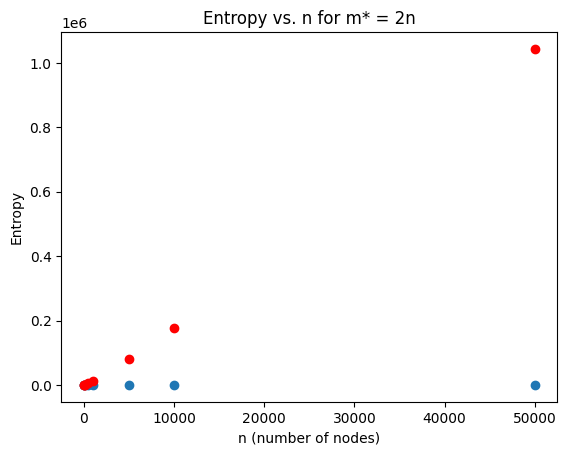

In [ ]:
plt.figure()
plt.scatter(n_list, entropy_list)
plt.scatter(n_list, ergm_entropy_list, c='red', label='Standard ERGM')
plt.xlabel('n (number of nodes)')
plt.ylabel('Entropy')
plt.title('Entropy vs. n for m* = 2n')
plt.show() 

m*       | k* (2m/n)    | Alpha            | Beta            
--------------------------------------------------------------
1        | 0.020000     | 1.5651252545     | -69.1930313407  
101      | 2.020000     | 13.3924254460    | -4.3574852910   
202      | 4.040000     | 18.0706423299    | -2.7164274999   
303      | 6.060000     | 21.5085385967    | -2.0213707604   
404      | 8.080000     | 24.3345350303    | -1.6175300034   
505      | 10.100000    | 26.7855525369    | -1.3462598998   
606      | 12.120000    | 28.9811622257    | -1.1478596144   
707      | 14.140000    | 30.9917739823    | -0.9943121956   
808      | 16.160000    | 32.8631643137    | -0.8705447111   
909      | 18.180000    | 34.6272812386    | -0.7676489688   
1010     | 20.200000    | 36.3076786500    | -0.6799835164   
1111     | 22.220000    | 37.9225226052    | -0.6037801756   
1212     | 24.240000    | 39.4863804377    | -0.5364123709   
1313     | 26.260000    | 41.0113505339    | -0.4759836428   
1414   

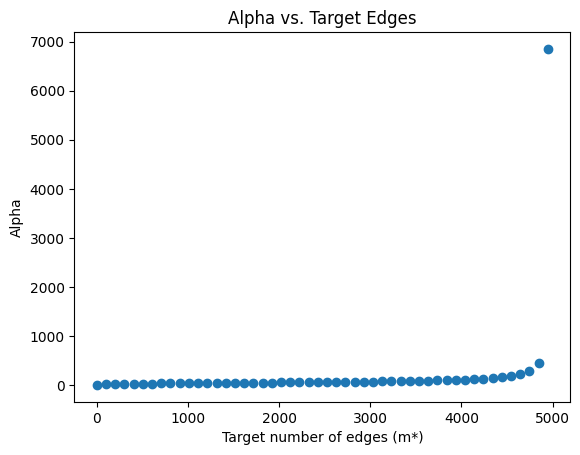

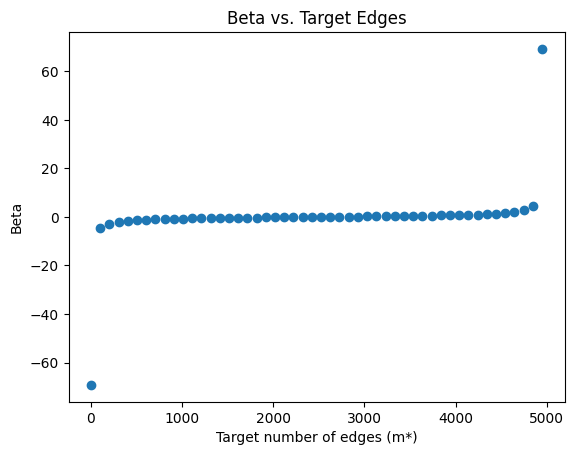

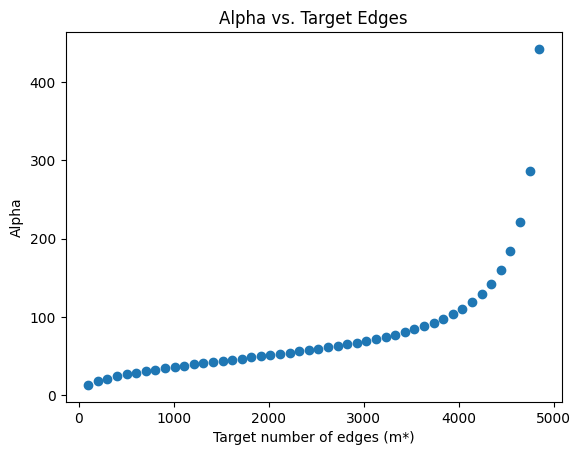

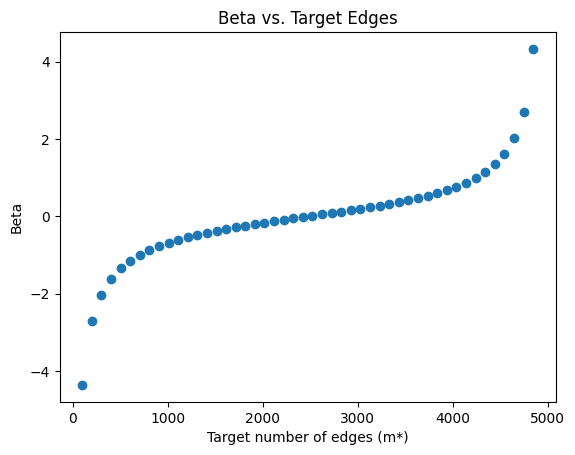

In [ ]:
import mpmath
import numpy as np
import matplotlib.pyplot as plt

# Set precision
mpmath.mp.dps = 40
mpmath.dps = 40

def solve_network_parameters(n, m_star):
    """
    Solve for alpha, beta when the exponential term uses:
        exp(-(alpha - beta * (2*m)/n)^2)
    Input: n (nodes), m_star (target number of edges)
    Returns: (alpha, beta) such that total_prob ~1 and expected_edges ~ m_star
    """
    nc2 = int(mpmath.binomial(n, 2))

    # Log of the Binomial Coefficient (height to suppress)
    ln_B = mpmath.log(mpmath.binomial(nc2, m_star))

    # Slope of log-Binomial at m_star
    binom_slope = mpmath.log((nc2 - m_star) / m_star)

    # The coefficient multiplying m inside the Gaussian is beta_m = beta * (2/n).
    # Use the same logic as before to get initial guesses for beta_m and alpha, then convert.
    delta = mpmath.sqrt(ln_B)                    # delta ~= (alpha - beta_m * m_star)
    beta_m_guess = -binom_slope / (2 * delta)    # guess for beta_m (coefficient on m)
    beta_guess = beta_m_guess * (n / 2)          # convert back to beta
    alpha_guess = beta_m_guess * m_star + delta  # alpha is in the term alpha - beta_m * m

    def equations(alpha, beta):
        total_prob = mpmath.mpf('0')
        expected_edges = mpmath.mpf('0')
        prev_total_prob = None
        prev_expected_edges = None
        for m in range(nc2 + 1):
            term = alpha - beta * (2 * m) / n
            prob = mpmath.binomial(nc2, m) * mpmath.exp(-term * term)
            total_prob += prob
            expected_edges += m * prob

            # small optimization: if values stop changing after passing m_star, break
            if m > m_star and prev_total_prob is not None:
                if total_prob == prev_total_prob and expected_edges == prev_expected_edges:
                    break
            prev_total_prob = total_prob
            prev_expected_edges = expected_edges

        return [total_prob - 1, expected_edges - m_star]

    def jacobian(alpha, beta):
        J11 = mpmath.mpf('0'); J12 = mpmath.mpf('0')
        J21 = mpmath.mpf('0'); J22 = mpmath.mpf('0')
        prev_J = [None, None, None, None]
        for m in range(nc2 + 1):
            term = alpha - beta * (2 * m) / n
            base_prob = mpmath.binomial(nc2, m) * mpmath.exp(-term ** 2)

            # d/dalpha of exp(-term^2) = exp(-term^2) * (-2*term) * d(term)/dalpha
            deriv_factor = -2 * term
            d_alpha = base_prob * deriv_factor * (1)            # dterm/dalpha = 1
            # d/dbeta: dterm/dbeta = -(2*m)/n
            d_beta = base_prob * deriv_factor * (-(2 * m) / n)

            J11 += d_alpha; J12 += d_beta
            J21 += m * d_alpha; J22 += m * d_beta

            current_J = [J11, J12, J21, J22]
            if m > m_star and current_J == prev_J:
                break
            prev_J = current_J

        return [[J11, J12], [J21, J22]]

    # Solver loop with fallbacks
    solvers = ['mdnewton', 'anderson', 'secant']
    for solver in solvers:
        try:
            kwargs = {'tol': 1e-10}
            if solver == 'mdnewton':
                kwargs['J'] = jacobian
            root = mpmath.findroot(equations, [alpha_guess, beta_guess], solver=solver, **kwargs)
            return float(root[0]), float(root[1])
        except Exception:
            continue

    print(f"  [Error] All solvers failed for m={m_star}")
    return None, None

# --- Verification Run ---
n = 100
nc2 = int(mpmath.binomial(n, 2))

# Test points (avoid m=0 and m=nc2 to prevent log(0) inside guesses)
test_points = np.linspace(1, nc2 - 1, 50, dtype=int)

print(f"{'m*':<8} | {'k* (2m/n)':<12} | {'Alpha':<16} | {'Beta':<16}")
print("-" * 62)

m_star_list = []
k_star_list = []
alpha_list = []
beta_list = []
for m_star in test_points:
    alpha, beta = solve_network_parameters(n, int(m_star))
    if alpha is not None:
        k_star = 2 * m_star / n
        print(f"{m_star:<8} | {k_star:<12.6f} | {alpha:<16.10f} | {beta:<16.10f}")
        m_star_list.append(m_star)
        k_star_list.append(k_star)
        alpha_list.append(alpha)
        beta_list.append(beta)

# Quick scatter plots
plt.figure()
plt.scatter(m_star_list, alpha_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')

plt.figure()
plt.scatter(m_star_list, beta_list)
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.figure()
plt.scatter(m_star_list[1:-1], alpha_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Alpha')
plt.title('Alpha vs. Target Edges')

plt.figure()
plt.scatter(m_star_list[1:-1], beta_list[1:-1])
plt.xlabel('Target number of edges (m*)')
plt.ylabel('Beta')
plt.title('Beta vs. Target Edges')

plt.show()

In [ ]:
def calculate_entropy(alpha, beta, nc2):
    nc2 = int(nc2)
    total_entropy = 0
    prev_total = -1
    for m in range(nc2 + 1):
        square_term = alpha - beta * m
        p = mpmath.exp(-square_term * square_term)
        entropy = p * mpmath.sqrt(-mpmath.log(p)) + (mpmath.sqrt(mpmath.pi) / 2) * mpmath.erfc(mpmath.sqrt(-mpmath.log(p)))
        total_entropy += mpmath.binomial(nc2, m) * entropy
        if total_entropy == prev_total:
            break
        prev_total = total_entropy
    return total_entropy

In [ ]:
gamma = None

In [ ]:
def run_chain(G, m, t, n, alpha, beta, gamma):
    max_its = 1000000
    check_interval = 50000
    tol = 0.01  # relative convergence tolerance
    converged = False
    prev_avg_edges = None
    prev_avg_tris = None

    H_old_sq = (alpha - beta * m - gamma * t) ** 2
    
    converged = False
    total_iter = 0
    
    # Run in batches until converged or max_its reached
    while total_iter < max_its and not converged:
        
        batch_edges = 0
        batch_tris = 0
        
        # The MCMC Batch
        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j: i, j = np.random.randint(0, n, 2)

            common = G.number_of_common_neighbors(i, j, m)
            
            if G.has_edge(i, j):
                delta_m = -1
                delta_t = -common
                # Proposed change
                m_new = m + delta_m
                t_new = t + delta_t
                H_new_sq = (alpha - beta * m_new - gamma * t_new) ** 2
                dH = H_old_sq - H_new_sq # Energy minimization
                
                if np.log(np.random.uniform()) <= dH:
                    G.remove_edge(i, j)
                    m = m_new
                    t = t_new
                    H_old_sq = H_new_sq
            else:
                delta_m = 1
                delta_t = common
                m_new = m + delta_m
                t_new = t + delta_t
                H_new_sq = (alpha - beta * m_new - gamma * t_new) ** 2
                dH = H_old_sq - H_new_sq
                
                if np.log(np.random.uniform()) <= dH:
                    G.add_edge(i, j)
                    m = m_new
                    t = t_new
                    H_old_sq = H_new_sq
            
            # Accumulate stats for this batch
            batch_edges += m
            batch_tris += t
            
        # -- Check Convergence --
        total_iter += check_interval
        avg_edges = batch_edges / check_interval
        avg_tris = batch_tris / check_interval
        
        # Calculate relative change
        if prev_avg_edges is not None: # Skip first check
            diff_e = abs(avg_edges - prev_avg_edges) / (prev_avg_edges + 1e-9)
            diff_t = abs(avg_tris - prev_avg_tris) / (prev_avg_tris + 1e-9)
            
            if diff_e < tol and diff_t < tol:
                converged = True
        
        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    return m, t


In [ ]:
class graphWithComplement:

    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

    def add_edge(self, u, v):
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)

    def remove_edge(self, u, v):
        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)

    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)
    
    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m<self.half_of_all_edges:
            return len(nx.common_neighbors(self.graph, u, v))
        else:
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

In [ ]:
import time
import numpy as np
import networkx as nx
from tqdm.notebook import tqdm
n = 500

alpha_vals = np.linspace(-3, 3, 11)
beta_vals = np.linspace(-1, 1, 20)
gamma_vals = np.linspace(-0.5, 0.5, 20)

max_edges = n*(n-1)//2
max_tris = n*(n-1)*(n-2)//6

empty_edge_results = {}
full_edge_results = {}
empty_tri_results = {}
full_tri_results = {}

for alpha in tqdm(alpha_vals, desc = "alpha", position=0):
    empty_edge_results[alpha] = []
    full_edge_results[alpha] = []
    empty_tri_results[alpha] = []
    full_tri_results[alpha] = []
    for beta in tqdm(beta_vals, desc = "  beta", position=1, leave=False):
        for gamma in tqdm(gamma_vals, desc = "    gamma", position=2, leave=False):
            start_time = time.time()
            G_empty = graphWithComplement(n, p=0.1)
            m_empty = G_empty.graph.number_of_edges()
            t_empty = sum(nx.triangles(G_empty.graph).values()) // 3
            G_full= graphWithComplement(n, p=0.9)
            m_full = G_full.graph.number_of_edges()
            t_full = sum(nx.triangles(G_full.graph).values()) // 3

            m_empty, t_empty = run_chain(G_empty, m_empty, t_empty, n, alpha, beta, gamma)
            m_full, t_full = run_chain(G_full, m_full, t_full, n, alpha, beta, gamma)

            elapsed = time.time() - start_time
            print(f"alpha = {alpha:.4f}, beta = {beta:.4f}, gamma = {gamma:.4f}, time = {elapsed:.2f}s, {m_empty}/{max_edges} edges (empty start), {m_full}/{max_edges} edges (full start), {t_empty}/{max_tris} tris (empty start), {t_full}/{max_tris} tris (full start)")
            empty_edge_results[alpha].append(m_empty/max_edges)
            full_edge_results[alpha].append(m_full/max_edges)
            empty_tri_results[alpha].append(t_empty/max_tris)
            full_tri_results[alpha].append(t_full/max_tris)

alpha:   0%|          | 0/11 [00:00<?, ?it/s]

  beta:   0%|          | 0/20 [00:00<?, ?it/s]

    gamma:   0%|          | 0/20 [00:00<?, ?it/s]

alpha = -3.0000, beta = -1.0000, gamma = -0.5000, time = 72.42s, 8/124750 edges (empty start), 29/124750 edges (full start), 0/20708500 tris (empty start), 0/20708500 tris (full start)


KeyboardInterrupt: 

In [ ]:
def run_simulation_step(alpha, beta, gamma, n, max_edges, max_tris):
    # 1. Setup Graphs
    G_empty = graphWithComplement(n, p=0.1)
    m_empty = G_empty.graph.number_of_edges()
    t_empty = sum(nx.triangles(G_empty.graph).values()) // 3
    
    G_full = graphWithComplement(n, p=0.9)
    m_full = G_full.graph.number_of_edges()
    t_full = sum(nx.triangles(G_full.graph).values()) // 3

    # 2. Run Chain
    m_empty, t_empty = run_chain(G_empty, m_empty, t_empty, n, alpha, beta, gamma)
    m_full, t_full = run_chain(G_full, m_full, t_full, n, alpha, beta, gamma)

    # 3. Calculate metrics
    res_empty_edge = m_empty / max_edges
    res_full_edge = m_full / max_edges
    res_empty_tri = t_empty / max_tris
    res_full_tri = t_full / max_tris
    
    # Return everything needed to reconstruct the results
    return (alpha, beta, gamma, res_empty_edge, res_full_edge, res_empty_tri, res_full_tri)

In [ ]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import itertools
import numpy as np
import networkx as nx
# 1. Create a list of all parameter combinations
# itertools.product is equivalent to nested for-loops
alpha_vals = [-3000, 0, 3000]
beta_vals = np.linspace(-0.04, 0.04, 20)
gamma_vals = np.linspace(-0.0004, 0.0004, 20)
param_list = list(itertools.product(alpha_vals, beta_vals, gamma_vals))

print(f"Total simulations to run: {len(param_list)}")
n=500
max_edges = n*(n-1)//2
max_tris = n*(n-1)*(n-2)//6
print(f"Max edges: {max_edges}, Max triangles: {max_tris}")
# 2. Run Parallel Jobs
# n_jobs=-1 uses all available CPU cores. 
# n_jobs=-2 uses all but one (keeps computer responsive).
results_flat = Parallel(n_jobs=-1)(
    delayed(run_simulation_step)(a, b, g, n, max_edges, max_tris) 
    for a, b, g in tqdm(param_list, desc="Running Simulations")
)

Total simulations to run: 1200
Max edges: 124750, Max triangles: 20708500


Running Simulations:   0%|          | 0/1200 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

# 1. Convert the flat results list directly into a DataFrame
df = pd.DataFrame(results_flat, columns=[
    'alpha', 'beta', 'gamma', 
    'empty_edge', 'full_edge', 'empty_tri', 'full_tri'
])
df.to_pickle("simulation_results_3.pkl")
# 2. View the first few rows (safe print)
print(df.head())

# 3. How to use it later:
# Example: Get all results where alpha is -3.0
subset = df[df['alpha'] == -3.0]

# Example: Get the empty_edge result for specific parameters
val = df.loc[
    (df['alpha'] == -3.0) & 
    (df['beta'] == -1.0) & 
    (df['gamma'] == 0.5), 
    'empty_edge'
]

   alpha  beta     gamma  empty_edge  full_edge  empty_tri  full_tri
0  -3000 -0.04 -0.000400    0.450164   0.450092   0.091163  0.091093
1  -3000 -0.04 -0.000358    0.458541   0.458293   0.096328  0.096264
2  -3000 -0.04 -0.000316    0.467471   0.467559   0.102111  0.102159
3  -3000 -0.04 -0.000274    0.477611   0.477539   0.108941  0.108922
4  -3000 -0.04 -0.000232    0.489050   0.488946   0.116885  0.116934


In [ ]:
import pandas as pd
df = pd.read_pickle("simulation_results.pkl")
print(df.head())

   alpha  beta     gamma  empty_edge  full_edge  empty_tri  full_tri
0   -3.0  -1.0 -0.500000    0.000064   0.000200        0.0       0.0
1   -3.0  -1.0 -0.447368    0.000056   0.000337        0.0       0.0
2   -3.0  -1.0 -0.394737    0.000064   0.000361        0.0       0.0
3   -3.0  -1.0 -0.342105    0.000064   0.000321        0.0       0.0
4   -3.0  -1.0 -0.289474    0.000056   0.000337        0.0       0.0


In [ ]:
import pandas as pd
df = pd.read_pickle("simulation_results_2.pkl")
print(df.head())

   alpha  beta     gamma  empty_edge  full_edge  empty_tri  full_tri
0  -3000 -0.04 -0.000400    0.450068   0.450036   0.091113  0.091141
1  -3000 -0.04 -0.000358    0.458293   0.458349   0.096275  0.096260
2  -3000 -0.04 -0.000316    0.467423   0.467663   0.102100  0.102152
3  -3000 -0.04 -0.000274    0.477611   0.477643   0.108940  0.108893
4  -3000 -0.04 -0.000232    0.488842   0.488882   0.116811  0.116880


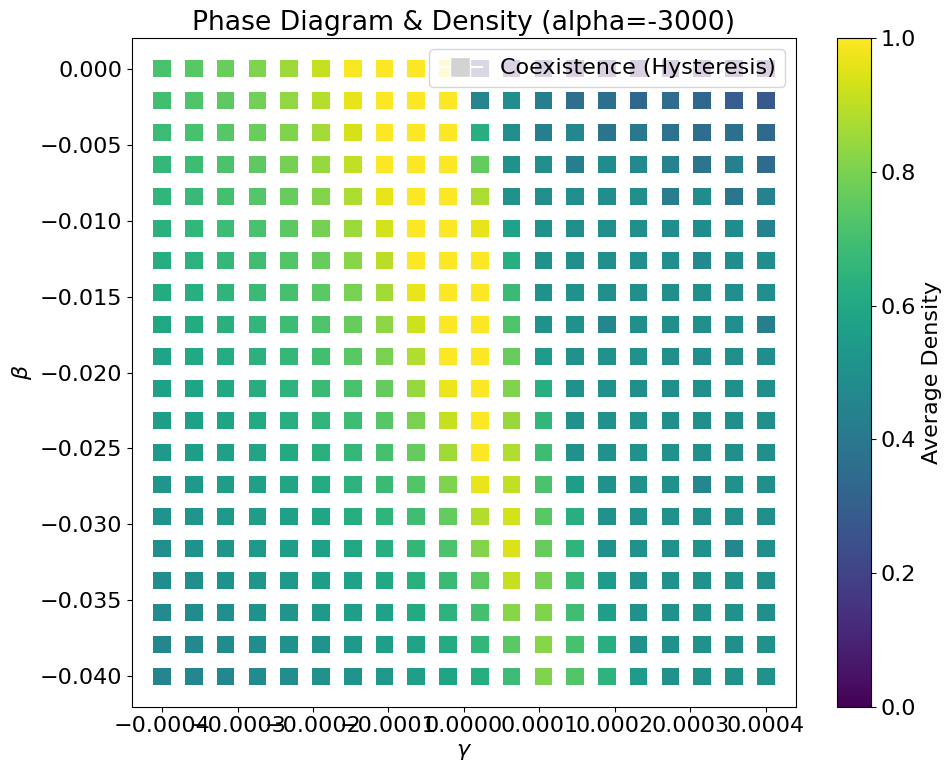

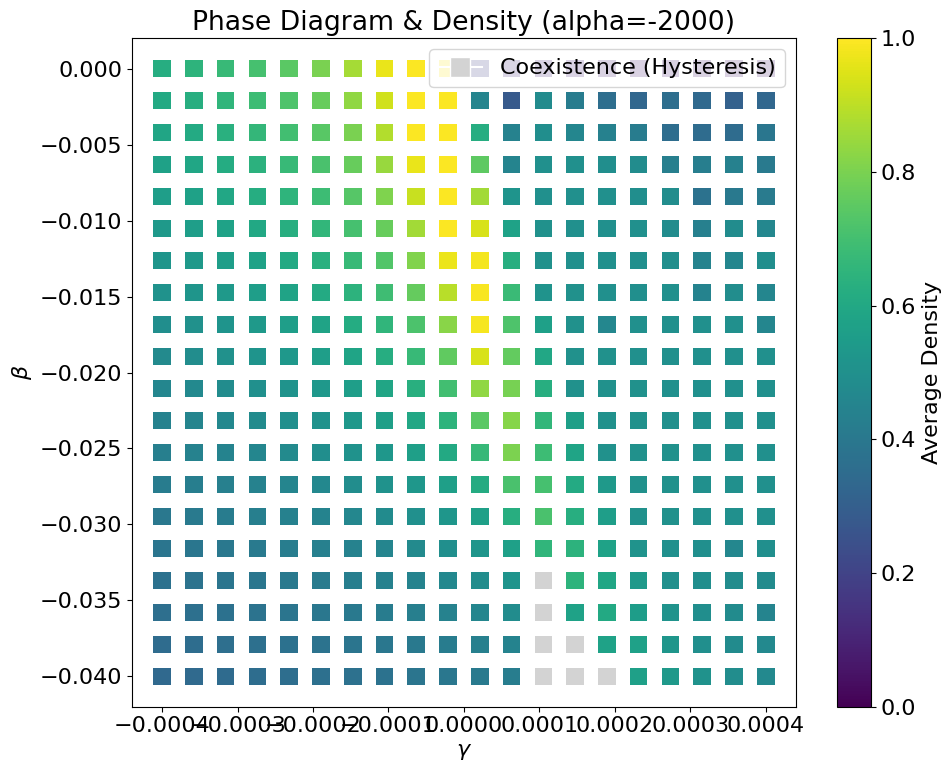

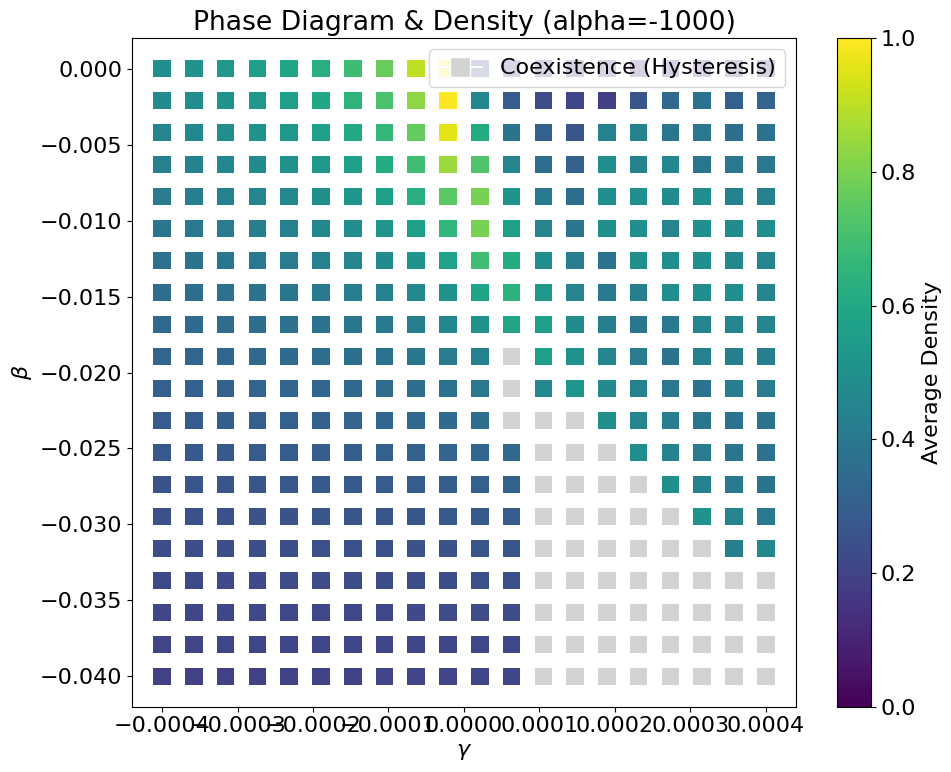

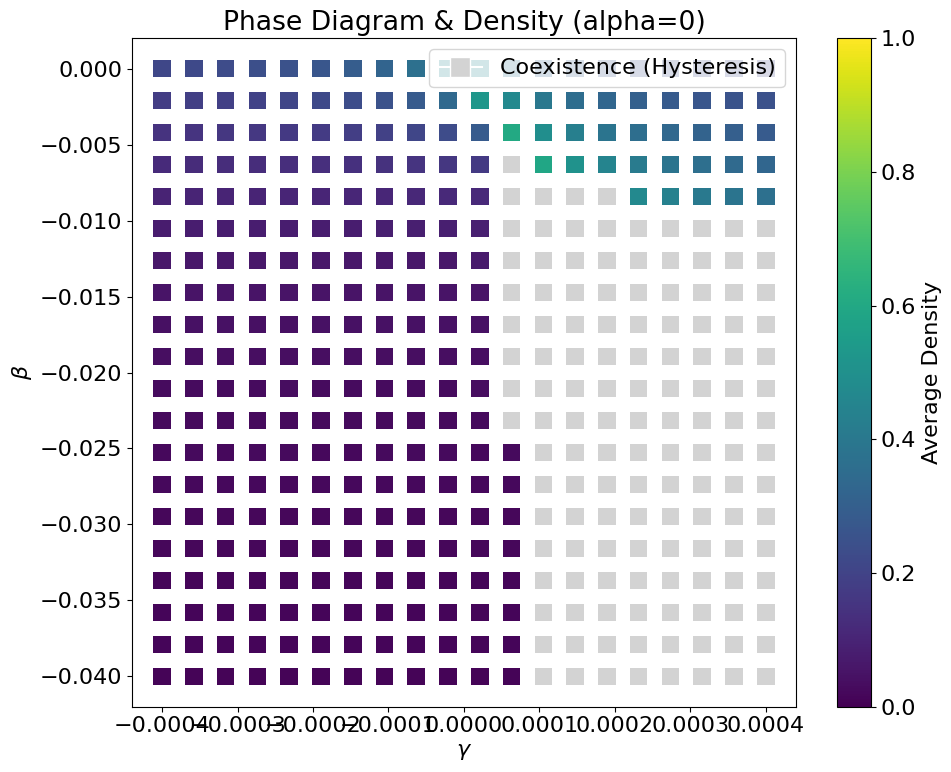

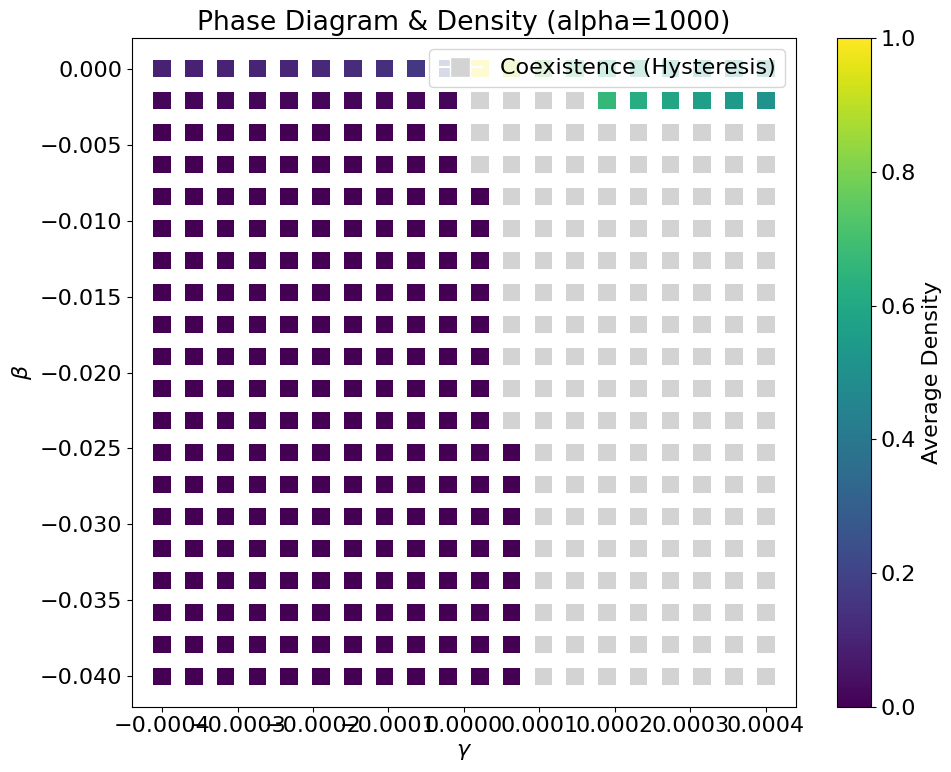

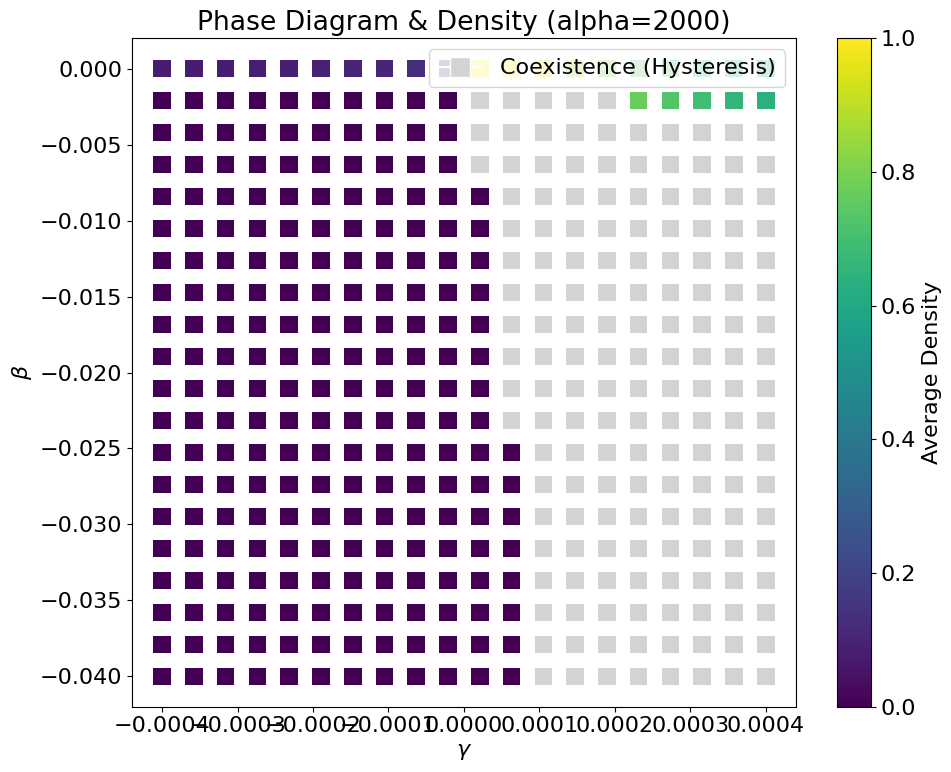

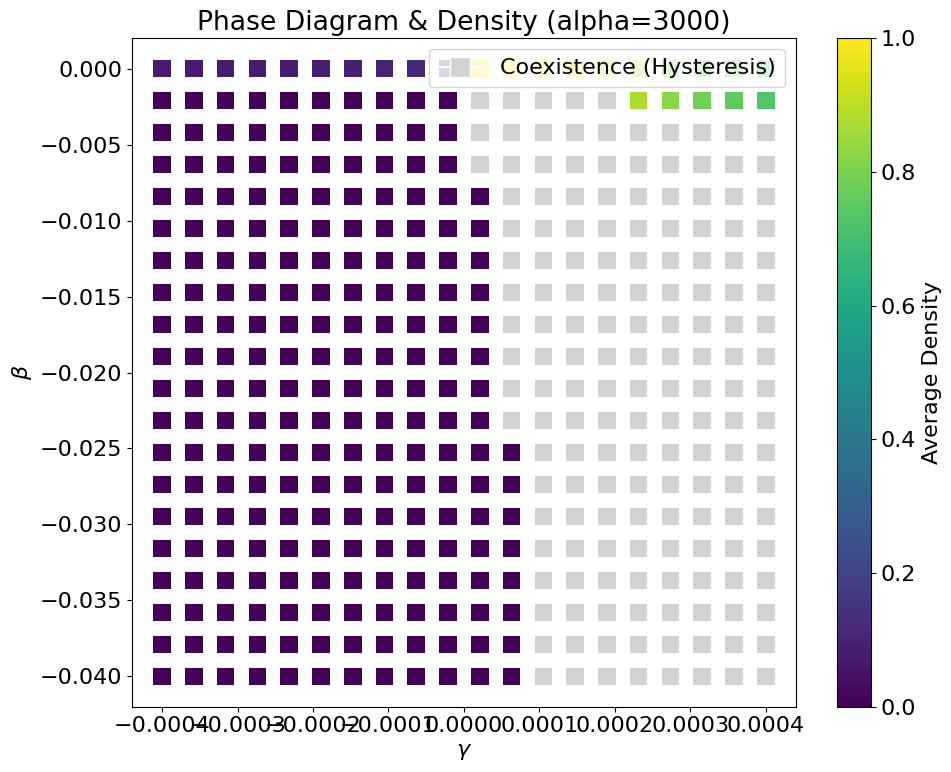

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# --- 1. Data Preparation ---
# Calculate metrics
df['diff'] = df['full_edge'] - df['empty_edge']
df['avg_density'] = (df['empty_edge'] + df['full_edge']) / 2.0

# Define Hysteresis Threshold
hyst_threshold = 0.2

# Split Data into two sets:
# 1. Hysteresis points (Coexistence)
hyst_mask = df['diff'] > hyst_threshold
hyst_df = df[hyst_mask]

# 2. Stable points (Low or High Density)
stable_df = df[~hyst_mask]

# --- 2. Plotting ---
unique_alphas = sorted(df['alpha'].unique())

import matplotlib 
matplotlib.rcParams.update({'font.size': 16})

for alpha in unique_alphas:
    # Filter for current alpha
    curr_stable = stable_df[stable_df['alpha'] == alpha]
    curr_hyst = hyst_df[hyst_df['alpha'] == alpha]
    
    plt.figure(figsize=(10, 8))
    
    # LAYER 1: The Density Heatmap (Stable points only)
    # vmin=0, vmax=1 locks the color scale so 0 is always purple/blue and 1 is yellow
    sc = plt.scatter(curr_stable['gamma'], curr_stable['beta'], 
                     c=curr_stable['avg_density'], 
                     cmap='viridis', 
                     s=160, marker='s', edgecolors='none',
                     vmin=0, vmax=1)
    
    # LAYER 2: The Hysteresis Overlay
    # Plot these points in solid gray to "mask" the density
    plt.scatter(curr_hyst['gamma'], curr_hyst['beta'], 
                c='lightgray', 
                s=160, marker='s', edgecolors='none')

    # --- Formatting ---

    # Colorbar (linked to the heatmap layer)
    cbar = plt.colorbar(sc)
    cbar.set_label('Average Density')

    # Custom Legend to explain the Gray region
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Coexistence (Hysteresis)',
               markerfacecolor='lightgray', markersize=15),
    ]
    # We add the legend, but keep it simple so it doesn't block data
    plt.legend(handles=legend_elements, loc='upper right', frameon=True)
    
    plt.xlabel(r'$\gamma$')
    plt.ylabel(r'$\beta$')
    plt.title(f"Phase Diagram & Density (alpha={alpha})")
    
    plt.tight_layout()
    plt.show()

In [15]:
import pandas as pd
df = pd.read_pickle("simulation_results_3.pkl")
print(df.head())

   alpha  beta     gamma  empty_edge  full_edge  empty_tri  full_tri
0  -3000 -0.04 -0.000400    0.450164   0.450092   0.091163  0.091093
1  -3000 -0.04 -0.000358    0.458541   0.458293   0.096328  0.096264
2  -3000 -0.04 -0.000316    0.467471   0.467559   0.102111  0.102159
3  -3000 -0.04 -0.000274    0.477611   0.477539   0.108941  0.108922
4  -3000 -0.04 -0.000232    0.489050   0.488946   0.116885  0.116934


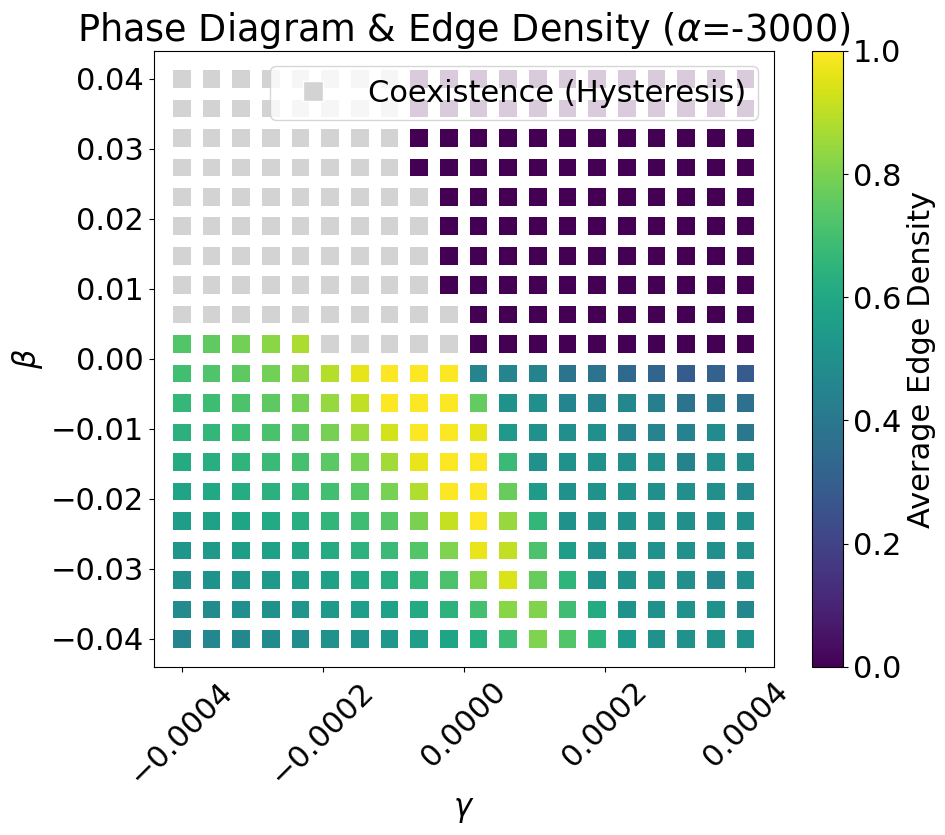

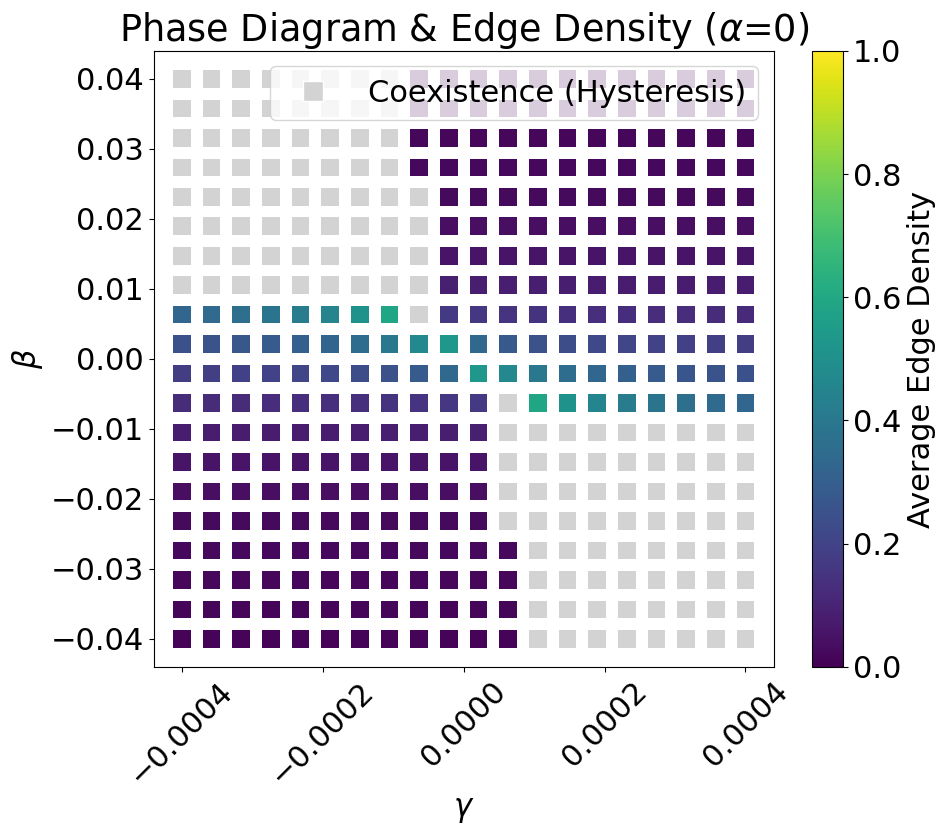

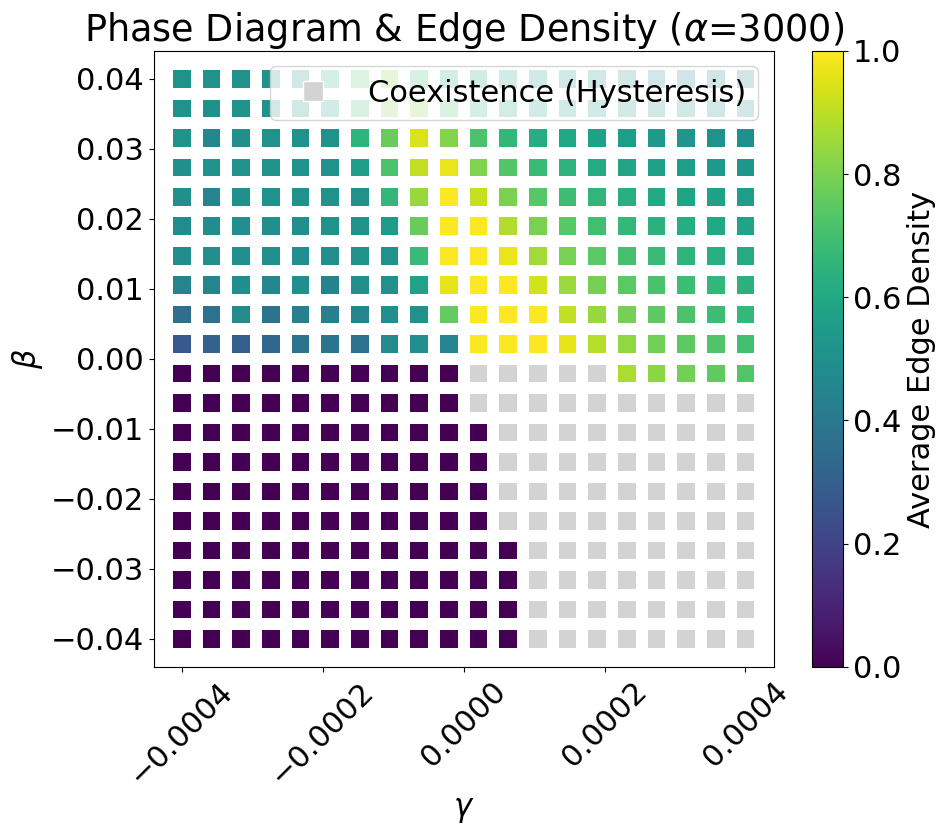

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# --- 1. Data Preparation ---
# Calculate metrics
df['diff'] = df['full_edge'] - df['empty_edge']
df['avg_density'] = (df['empty_edge'] + df['full_edge']) / 2.0

# Define Hysteresis Threshold
hyst_threshold = 0.2

# Split Data into two sets:
# 1. Hysteresis points (Coexistence)
hyst_mask = df['diff'] > hyst_threshold
hyst_df = df[hyst_mask]

# 2. Stable points (Low or High Density)
stable_df = df[~hyst_mask]

# --- 2. Plotting ---
unique_alphas = sorted(df['alpha'].unique())

import matplotlib 
matplotlib.rcParams.update({'font.size': 22})

for alpha in unique_alphas:
    # Filter for current alpha
    curr_stable = stable_df[stable_df['alpha'] == alpha]
    curr_hyst = hyst_df[hyst_df['alpha'] == alpha]
    
    plt.figure(figsize=(10, 8))
    
    # LAYER 1: The Density Heatmap (Stable points only)
    # vmin=0, vmax=1 locks the color scale so 0 is always purple/blue and 1 is yellow
    sc = plt.scatter(curr_stable['gamma'], curr_stable['beta'], 
                     c=curr_stable['avg_density'], 
                     cmap='viridis', 
                     s=160, marker='s', edgecolors='none',
                     vmin=0, vmax=1)
    
    # LAYER 2: The Hysteresis Overlay
    # Plot these points in solid gray to "mask" the density
    plt.scatter(curr_hyst['gamma'], curr_hyst['beta'], 
                c='lightgray', 
                s=160, marker='s', edgecolors='none')

    # --- Formatting ---

    # Colorbar (linked to the heatmap layer)
    cbar = plt.colorbar(sc)
    cbar.set_label('Average Edge Density')

    # Custom Legend to explain the Gray region
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Coexistence (Hysteresis)',
               markerfacecolor='lightgray', markersize=15),
    ]
    # We add the legend, but keep it simple so it doesn't block data
    plt.legend(handles=legend_elements, loc='upper right', frameon=True)
    
    
    plt.xlabel(r'$\gamma$')
    plt.ylabel(r'$\beta$')
    plt.title(r"Phase Diagram & Edge Density ($\alpha$="+f"{alpha})")
    plt.xticks(rotation=45)
    
    plt.show()

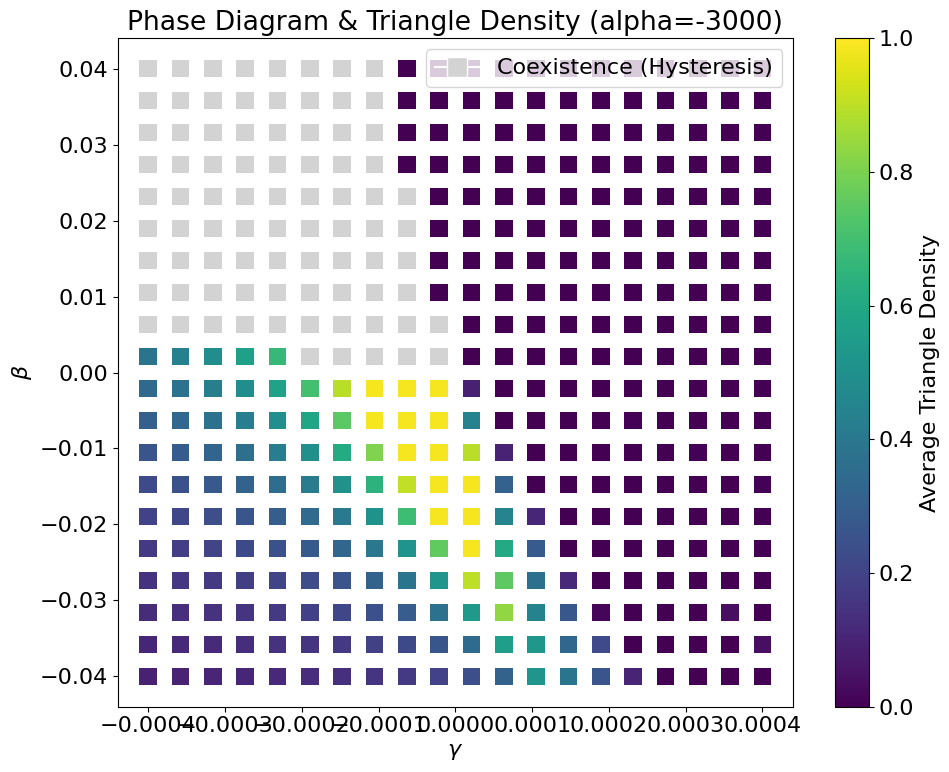

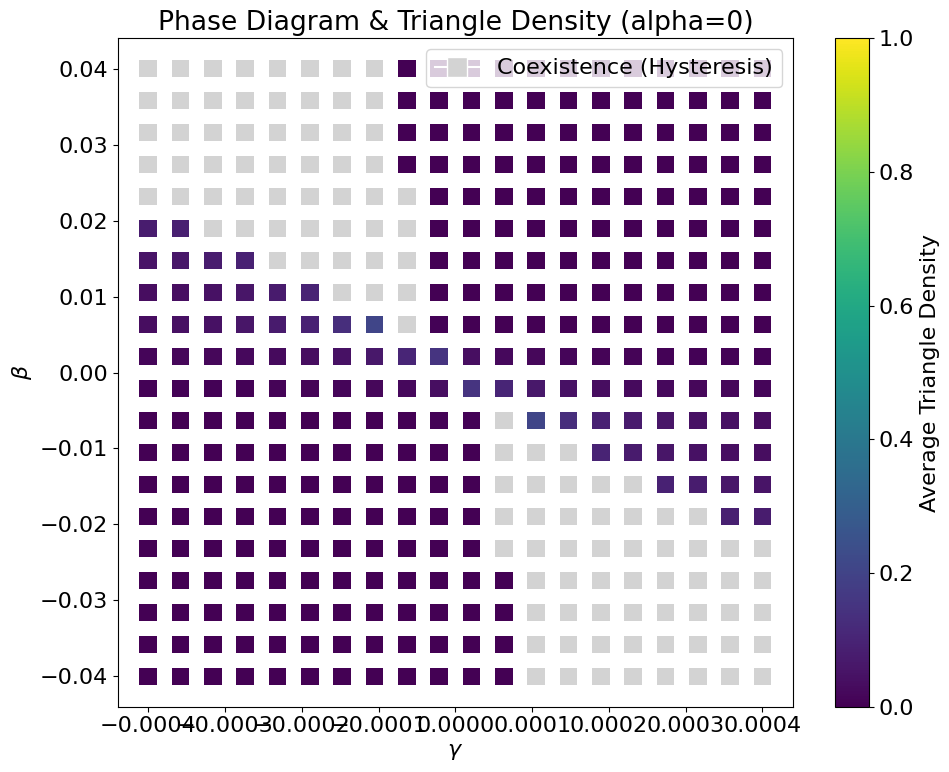

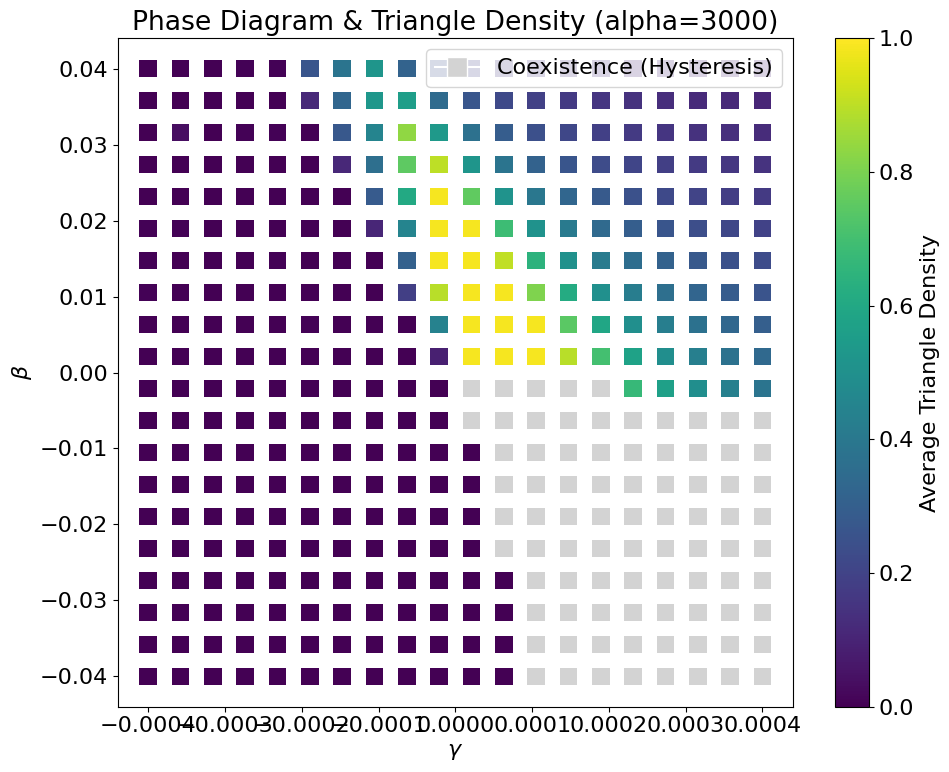

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# --- 1. Data Preparation ---
# Calculate metrics
df['diff'] = df['full_tri'] - df['empty_tri']
df['avg_density'] = (df['empty_tri'] + df['full_tri']) / 2.0

# Define Hysteresis Threshold
hyst_threshold = 0.2

# Split Data into two sets:
# 1. Hysteresis points (Coexistence)
hyst_mask = df['diff'] > hyst_threshold
hyst_df = df[hyst_mask]

# 2. Stable points (Low or High Density)
stable_df = df[~hyst_mask]

# --- 2. Plotting ---
unique_alphas = sorted(df['alpha'].unique())

import matplotlib 
matplotlib.rcParams.update({'font.size': 16})

for alpha in unique_alphas:
    # Filter for current alpha
    curr_stable = stable_df[stable_df['alpha'] == alpha]
    curr_hyst = hyst_df[hyst_df['alpha'] == alpha]
    
    plt.figure(figsize=(10, 8))
    
    # LAYER 1: The Density Heatmap (Stable points only)
    # vmin=0, vmax=1 locks the color scale so 0 is always purple/blue and 1 is yellow
    sc = plt.scatter(curr_stable['gamma'], curr_stable['beta'], 
                     c=curr_stable['avg_density'], 
                     cmap='viridis', 
                     s=160, marker='s', edgecolors='none',
                     vmin=0, vmax=1)
    
    # LAYER 2: The Hysteresis Overlay
    # Plot these points in solid gray to "mask" the density
    plt.scatter(curr_hyst['gamma'], curr_hyst['beta'], 
                c='lightgray', 
                s=160, marker='s', edgecolors='none')

    # --- Formatting ---

    # Colorbar (linked to the heatmap layer)
    cbar = plt.colorbar(sc)
    cbar.set_label('Average Triangle Density')

    # Custom Legend to explain the Gray region
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Coexistence (Hysteresis)',
               markerfacecolor='lightgray', markersize=15),
    ]
    # We add the legend, but keep it simple so it doesn't block data
    plt.legend(handles=legend_elements, loc='upper right', frameon=True)
    
    plt.xlabel(r'$\gamma$')
    plt.ylabel(r'$\beta$')
    plt.title(f"Phase Diagram & Triangle Density (alpha={alpha})")
    
    plt.tight_layout()
    plt.show()